## Imports and Reading Results

In [ ]:
# install the package but not necessary locally
%env HTTP_PROXY=http://proxy:80
%env HTTPS_PROXY=http://proxy:80
%pip install -e .. 

env: HTTP_PROXY=http://proxy:80
env: HTTPS_PROXY=http://proxy:80
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/hpc/iwi7/iwi7101h/i7-IDS
  Preparing metadata (setup.py) ... done
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [tqdm]  WARNING: The script tqdm is installed in '/home/hpc/iwi7/iwi7101h/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: ids_expt━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
    Found existing installation: ids_expt 0.1━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
    Uninstalling ids_expt-0.1:m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
      Successfully uninstalled ids_expt-0.1╸━━━━━━━━

#### Settings for MPL

In [1]:
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font family and size
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "serif"]
mpl.rcParams["font.size"] = 12  # Adjust per Springer guidelines
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11

# Optional: PDF/LaTeX text rendering for enhanced output
mpl.rcParams["text.usetex"] = False

In [2]:
adv_block_path = Path("../results/adversarial_blocking")
save_dir = Path("../results/adversarial_blocking")

In [3]:
models = list(adv_block_path.iterdir())
models

[WindowsPath('../results/adversarial_blocking/mobilenet_v3_large_normalized_nosampling'),
 WindowsPath('../results/adversarial_blocking/mobilenet_v3_large_nosampling'),
 WindowsPath('../results/adversarial_blocking/resnet18_normalized_nosampling'),
 WindowsPath('../results/adversarial_blocking/resnet18_nosampling')]

## Adversarial Images

<>:145: SyntaxWarning: invalid escape sequence '\e'
<>:145: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Viper\AppData\Local\Temp\ipykernel_11056\2856032572.py:145: SyntaxWarning: invalid escape sequence '\e'
  title = f"$\epsilon={title}$"


[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


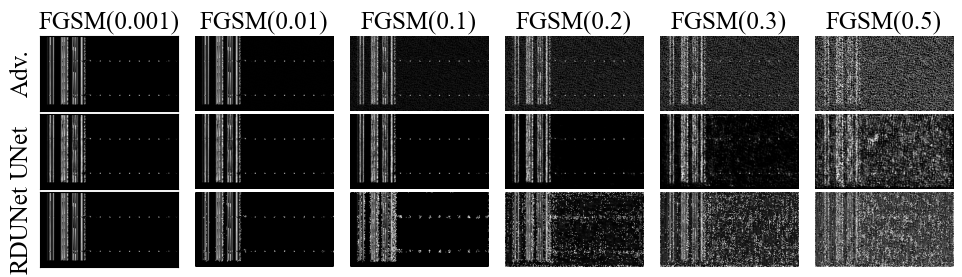

[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


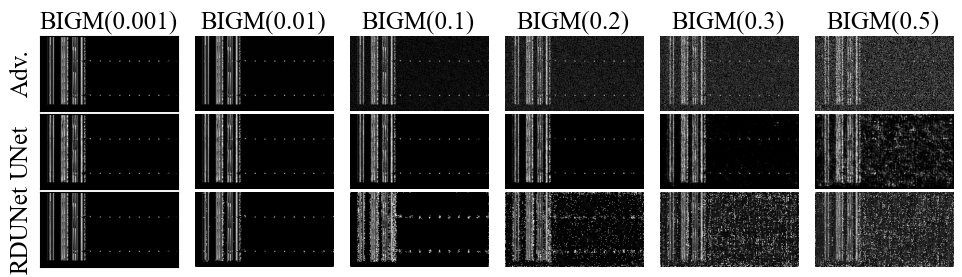

[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


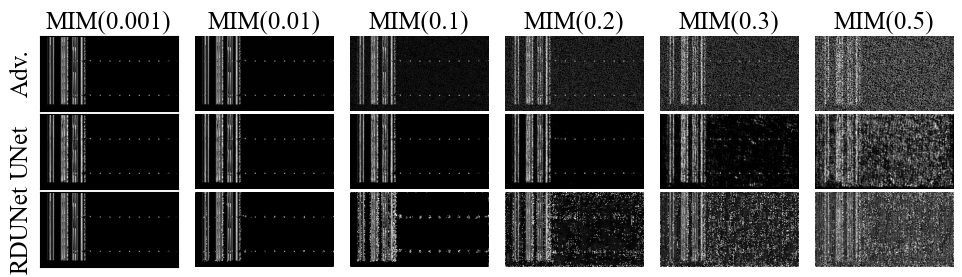

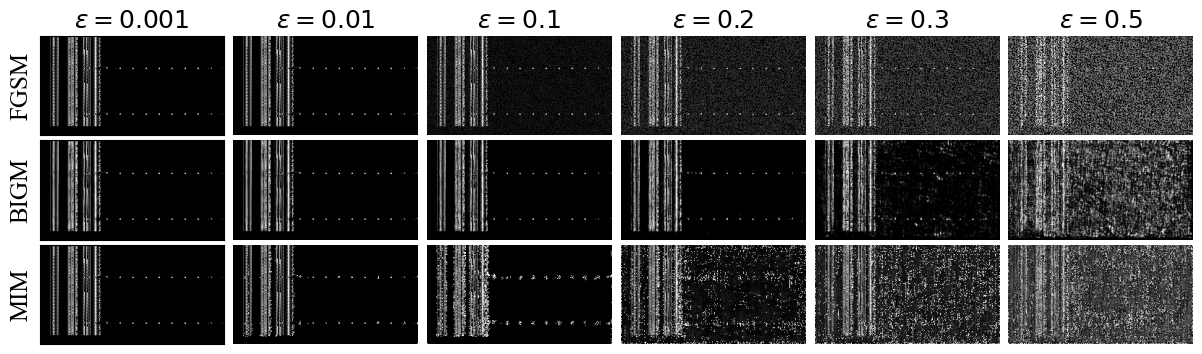

In [5]:
from collections import defaultdict
import cv2

label = "NORMAL"
generator_model = "resnet18_nosampling"
generator_model = "resnet18_normalized_nosampling"
generator_model = "mobilenet_v3_large_nosampling"
# generator_model = "mobilenet_v3_large_normalized_nosampling"
is_normalized = False
data_type = "normalized" if "normalized" in generator_model else "normal"

all_adv = []
all_adv_titles = []

images = [
    i
    for i in adv_block_path.rglob("*.png")
    if label in str(i.name) and generator_model in str(i) and data_type in str(i)
]

atk_names = list(set([i.parent.name for i in images]))
atk_eps = defaultdict(list)
atk_name_map = {}
for atk_name in atk_names:
    atk = (
        "FGSM"
        if "fast" in atk_name
        else "BIGM" if "basic" in atk_name else "MIM" if "momentum" in atk_name else ""
    )
    if atk == "":
        continue
    eps = float(atk_name.split("eps_")[-1])
    atk_name_map[atk] = atk_name.split("_eps")[0]
    atk_eps[atk].append(eps)


ae_models = ["unet_custom", "rdunet"]
ae_images = {}
completed_images = []
for atk, epsilons in atk_eps.items():
    adv_images = []
    unet_adv_images = []
    recon_unet = []
    recon_rdunet = []
    curr_titles = []
    epsilons = sorted(list(set(epsilons)))
    print(epsilons)
    for eps in epsilons:
        atk_folder = (
            adv_block_path
            / generator_model
            / "val"
            / f"{atk_name_map.get(atk)}_eps_{eps}"
        )
        for ae_model in ae_models:
            recon_image = f"{label}_{ae_model}_{data_type}_recon_adversarial.png"
            recon_image_path = atk_folder / recon_image
            adv_image = f"{label}_{ae_model}_{data_type}_adversarial.png"
            adv_image_path = atk_folder / adv_image

            if recon_image_path.exists() and adv_image_path.exists():
                (
                    recon_unet.append(recon_image_path)
                    if ae_model == "unet_custom"
                    else recon_rdunet.append(recon_image_path)
                )
                (
                    unet_adv_images.append(adv_image_path)
                    if ae_model == "unet_custom"
                    else adv_images.append(adv_image_path)
                )
                if ae_model == "unet_custom":
                    all_adv.append(adv_image_path)
                    all_adv_titles.append(f"{atk}({eps})")

                title = f"{atk}({eps})"
                if title not in curr_titles:
                    curr_titles.append(title)

    ncols = len(curr_titles)
    nrows = 3  # [adv_image, unet_recon, rdunet_recon]
    if ncols == 0:
        continue

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3))
    y_labels = ["Adv.", "UNet", "RDUNet"]

    for col in range(ncols):
        # Adversarial images (row 0)
        if col < len(adv_images):
            adv_img = cv2.imread(str(adv_images[col]))
            if adv_img is not None:
                axs[0, col].imshow(cv2.cvtColor(adv_img, cv2.COLOR_BGR2RGB))
            axs[0, col].set_title(curr_titles[col], fontsize=18)
        # UNet reconstructions (row 1)
        if col < len(recon_unet):
            recon_unet_img = cv2.imread(str(recon_unet[col]))
            if recon_unet_img is not None:
                axs[1, col].imshow(cv2.cvtColor(recon_unet_img, cv2.COLOR_BGR2RGB))
        # RDUNet reconstructions (row 2)
        if col < len(recon_rdunet):
            recon_rdunet_img = cv2.imread(str(recon_rdunet[col]))
            if recon_rdunet_img is not None:
                axs[2, col].imshow(cv2.cvtColor(recon_rdunet_img, cv2.COLOR_BGR2RGB))

    # Set y-label and y-ticks only on the left-most image of each row
    for row_idx, y_label in enumerate(y_labels):
        axs[row_idx, 0].set_ylabel(y_label, fontsize=18)
        axs[row_idx, 0].yaxis.set_visible(True)
        axs[row_idx, 0].spines["left"].set_visible(True)
        # Optionally, set larger yticks if you want extra visibility:
        # axs[row_idx, 0].tick_params(axis='y', labelsize=11)

    # Hide axis ticks for all other axes except left-most
    for row in range(nrows):
        for col in range(1, ncols):  # only right of leftmost
            axs[row, col].axis("off")
        # clear ticks from images
        axs[row, 0].set_xticks([])
        axs[row, 0].set_yticks([])
    # plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(
        f"{label}_{data_type}_{generator_model}_{atk}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.subplots_adjust(hspace=0.05, wspace=0.00)
    plt.show()

# now plot all adversarial images in one figure
ncols = 6
nrows = len(all_adv) // ncols + (1 if len(all_adv) % ncols > 0 else 0)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, int(1.5 * nrows)))
y_labels = atk_eps.keys()

for col in range(ncols):
    # Adversarial images (row 0)
    if col < len(adv_images):
        adv_img = cv2.imread(str(adv_images[col]))
        if adv_img is not None:
            axs[0, col].imshow(cv2.cvtColor(adv_img, cv2.COLOR_BGR2RGB))
        title = curr_titles[col]
        # only eps part
        title = title.split("(")[1].split(")")[0]
        title = f"$\epsilon={title}$"
        axs[0, col].set_title(title, fontsize=18)
    # UNet reconstructions (row 1)
    if col < len(recon_unet):
        recon_unet_img = cv2.imread(str(recon_unet[col]))
        if recon_unet_img is not None:
            axs[1, col].imshow(cv2.cvtColor(recon_unet_img, cv2.COLOR_BGR2RGB))
    # RDUNet reconstructions (row 2)
    if col < len(recon_rdunet):
        recon_rdunet_img = cv2.imread(str(recon_rdunet[col]))
        if recon_rdunet_img is not None:
            axs[2, col].imshow(cv2.cvtColor(recon_rdunet_img, cv2.COLOR_BGR2RGB))

# Set y-label and y-ticks only on the left-most image of each row
for row_idx, y_label in enumerate(y_labels):
    axs[row_idx, 0].set_ylabel(y_label, fontsize=18)
    axs[row_idx, 0].yaxis.set_visible(True)
    axs[row_idx, 0].spines["left"].set_visible(True)
    axs[row_idx, 0].set_xticks([])
    axs[row_idx, 0].set_yticks([])

# Hide axis for non-leftmost images and remove grid lines/gaps
for row in range(nrows):
    for col in range(1, ncols):
        axs[row, col].axis("off")

plt.subplots_adjust(hspace=0.05, wspace=0.00)

plt.savefig(f"{label}_{data_type}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## From JSON

In [112]:
import json

model_results = {}

for model in models:
    model_name = model.name
    results = model/'results.json'
    if not results.exists():
        continue
    with open(results) as fp:
        results = json.load(fp)
    model_results[model_name]=results
        

In [115]:
model_results

{'mobilenet_v3_large_normalized_nosampling': {'no_attack': {'f1_score': 0.9639418125152588,
   'blocked_f1_score': 0.4160230755805969,
   'mse_loss': 0.0006402666331268847,
   'confusion_matrix': [[128, 0, 0, 0, 38, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 665, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [60, 0, 0, 2, 3471, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 173, 0, 0, 0],
    [0, 0, 0, 0, 2, 0, 1438, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1403, 37],
    [0, 0, 0, 0, 0, 0, 0, 0, 1440]],
   'blocked_confusion_matrix': [[147, 0, 1, 5, 13, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 361, 304, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [1287, 0, 89, 513, 1601, 2, 0, 0, 43],
    [9, 0, 0, 0, 133, 31, 0, 0, 0],
    [1, 0, 0, 30, 136, 0, 207, 0, 1066],
    [18, 0, 0, 4, 96, 0, 0, 135, 1187],
    [1, 0, 0, 8, 38, 0, 0, 0, 1393]]},
  'FastGradientMethod_eps_0.0001': {'f1_score': 0.9104052782058716,
   'blocked_f1_score': 0.4156450033187866,
   

In [105]:
import pandas as pd

all_results = []

for model, results in model_results.items():
    for atk_type, result in results.items():
        if atk_type!='no_attack':
            eps = atk_type.split('eps_')[-1]
            atk_name =  atk_type.split('eps_')[0]
            atk_name = 'FGSM' if 'Fast' in atk_name else 'BIGM'
            eps=float(eps)
        else:
            eps = 0
            atk_name = 'NA'
        f1 = result['f1_score']
        blocked_f1 = result['blocked_f1_score']
        mse_loss = result['mse_loss']
        all_results.append([model, atk_name, eps, f1, blocked_f1, mse_loss])

res_df = pd.DataFrame(all_results, columns=['model','atk', 'eps', 'f1', 'blocked_f1','mse'])
res_df
    

,model,atk,eps,f1,blocked_f1,mse
0,mobilenet_v3_large_normalized_nosampling,NA,0.0000,0.963942,0.416023,0.000640
1,mobilenet_v3_large_normalized_nosampling,FGSM,0.0001,0.910405,0.415645,0.000641
2,mobilenet_v3_large_normalized_nosampling,FGSM,0.0010,0.360729,0.411204,0.000643
3,mobilenet_v3_large_normalized_nosampling,FGSM,0.0100,0.317456,0.405659,0.000653
4,mobilenet_v3_large_normalized_nosampling,FGSM,0.1000,0.058972,0.227177,0.000714
5,mobilenet_v3_large_normalized_nosampling,BIGM,0.0001,0.897192,0.415720,0.000641
6,mobilenet_v3_large_normalized_nosampling,BIGM,0.0010,0.062080,0.411625,0.000642
7,mobilenet_v3_large_normalized_nosampling,BIGM,0.0100,0.020248,0.415548,0.000650
8,mobilenet_v3_large_normalized_nosampling,BIGM,0.1000,0.001857,0.274971,0.000695
9,resnet18_nosampling_adv,NA,0.0000,0.921701,0.812616,0.019462


In [106]:
df = res_df.copy()


In [107]:
df.model.unique()

array(['mobilenet_v3_large_normalized_nosampling',
       'resnet18_nosampling_adv', 'resnet18_normalized_nosampling_adv',
       'resnet18_nosampling', 'resnet18_normalized_nosampling'],
      dtype=object)

In [108]:
def plot_groupped_bars(df:pd.DataFrame, save_as:Path,title:str='F1 and Blocked F1'): 
    
    groups = ['No Attack', 'ε=0.0001', 'ε=0.001', 'ε=0.01', 'ε=0.1']
    
    # Plot style
    sns.set_theme(style="whitegrid", font="serif", rc={
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    for ax, attack in zip(axes, ['FGSM', 'BIGM']):
        records = []
        # Baseline
        base = df[df['atk']=='NA'].iloc[0]
        records += [
            {'group': 'No Attack', 'metric': 'F1',         'score': base['f1']},
            {'group': 'No Attack', 'metric': 'Blocked F1','score': base['blocked_f1']}
        ]
        # Adversarial groups
        for eps in [0.0001, 0.001, 0.01, 0.1]:
            row = df[(df['atk']==attack)&(df['eps']==eps)].iloc[0]
            label = f'ε={eps}'
            records += [
                {'group': label, 'metric': 'F1',         'score': row['f1']},
                {'group': label, 'metric': 'Blocked F1','score': row['blocked_f1']}
            ]
        plot_df = pd.DataFrame.from_records(records)
    
        sns.barplot(
            data=plot_df,
            x='group',
            y='score',
            hue='metric',
            ax=ax,
            palette=['#2E86AB', '#A0C5E8'],
            edgecolor='black'
        )
        ax.set_title(f'{attack} Attack')
        ax.set_xlabel('')
        if ax is axes[0]:
            ax.set_ylabel('Score')
        else:
            ax.set_ylabel('')
        ax.set_ylim(0, 1.0)
        ax.set_yticks([i/10 for i in range(0, 11)])
        ax.grid(axis='y', linestyle='--', color='gray', alpha=0.5)
    
        # Annotate
        for p in ax.patches:
            h = p.get_height()
            # Only annotate if height is meaningful
            if h < 0.01:
                continue
            ax.annotate(f'{h:.2f}',
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=10)
        ax.legend(title='Metric')
    
    # Final touches
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_as, dpi=300)
    plt.show()



mobilenet_v3_large_normalized_nosampling


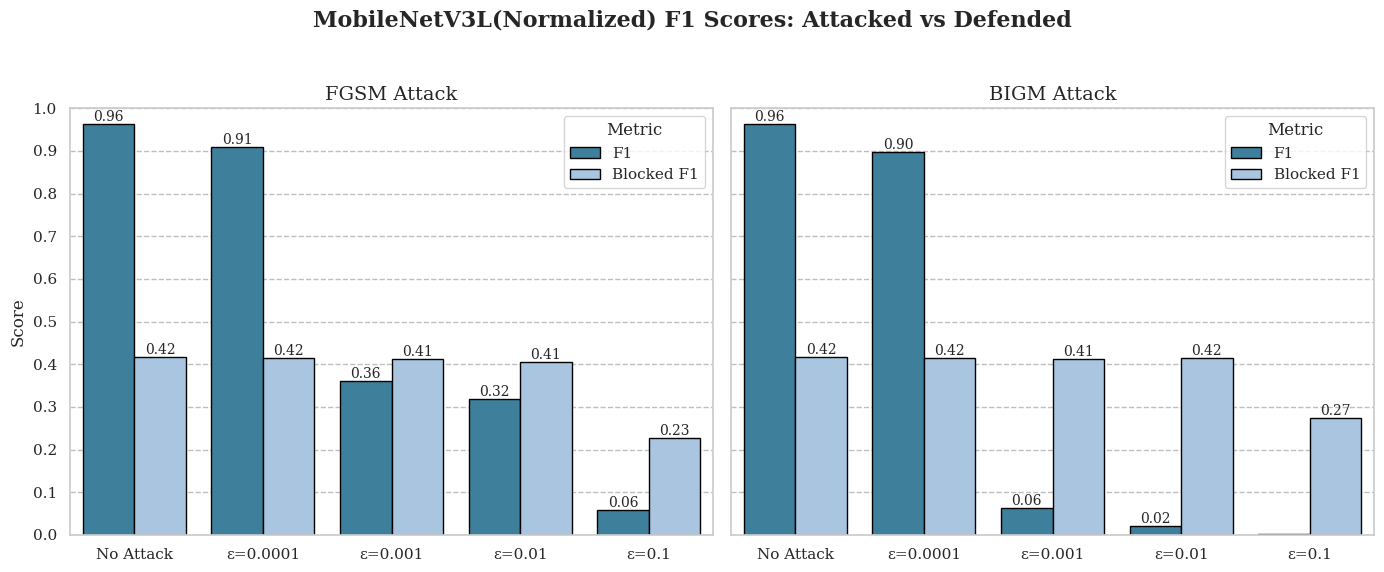

resnet18_nosampling_adv


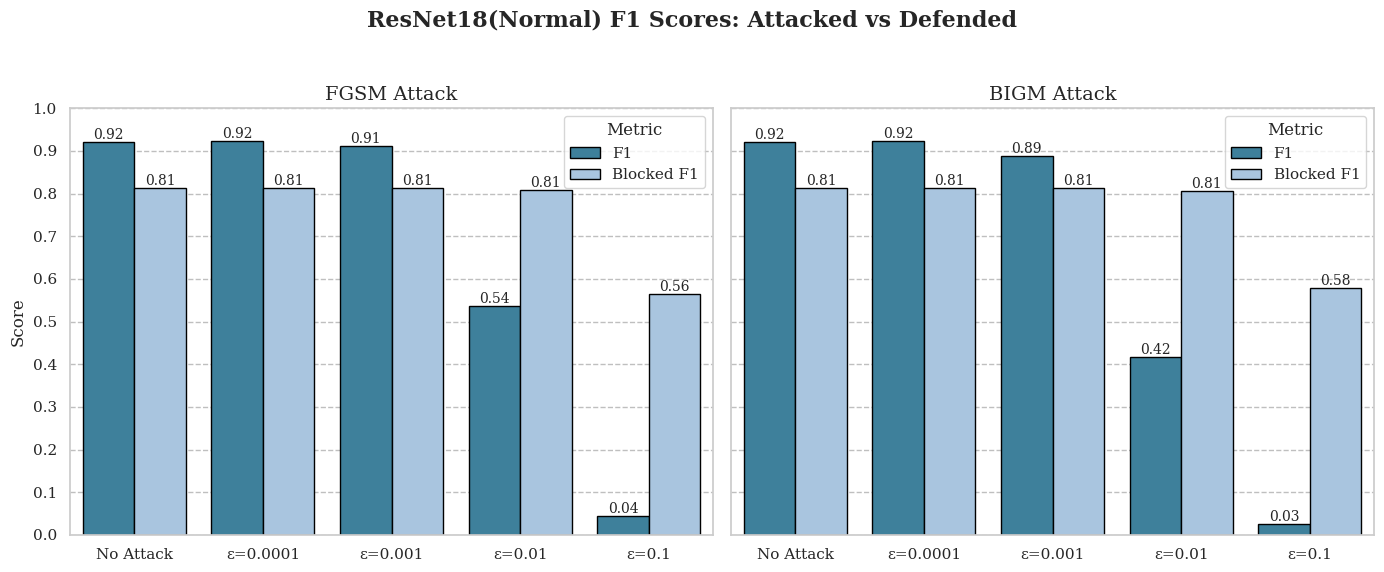

resnet18_normalized_nosampling_adv


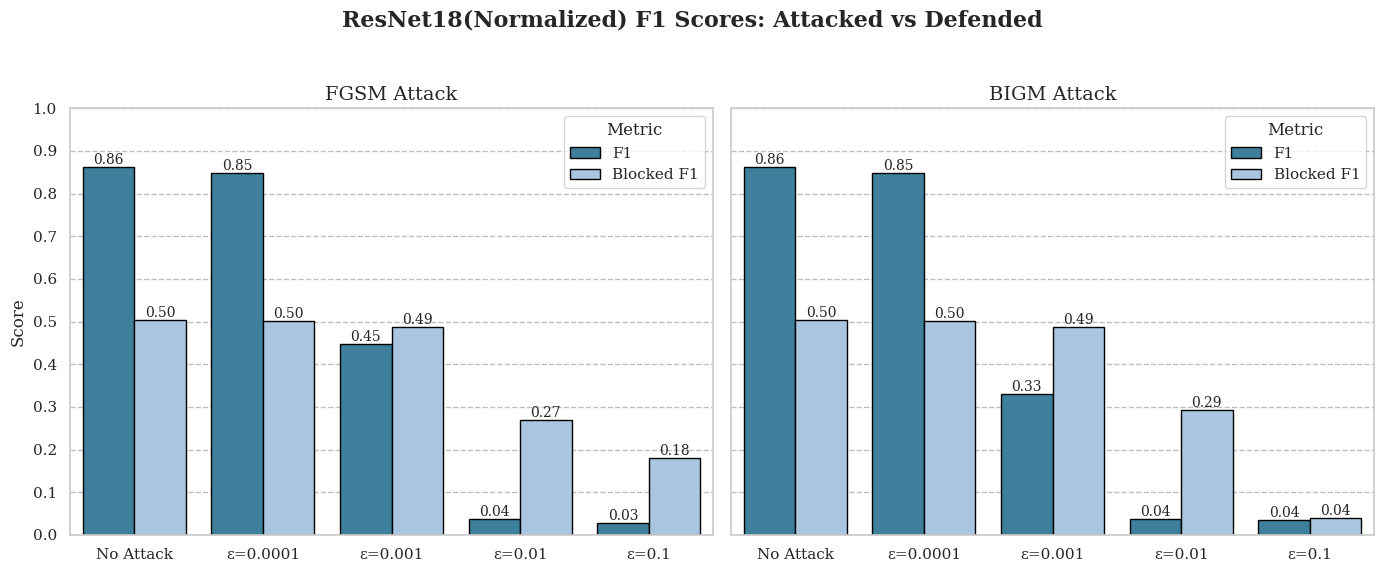

resnet18_nosampling


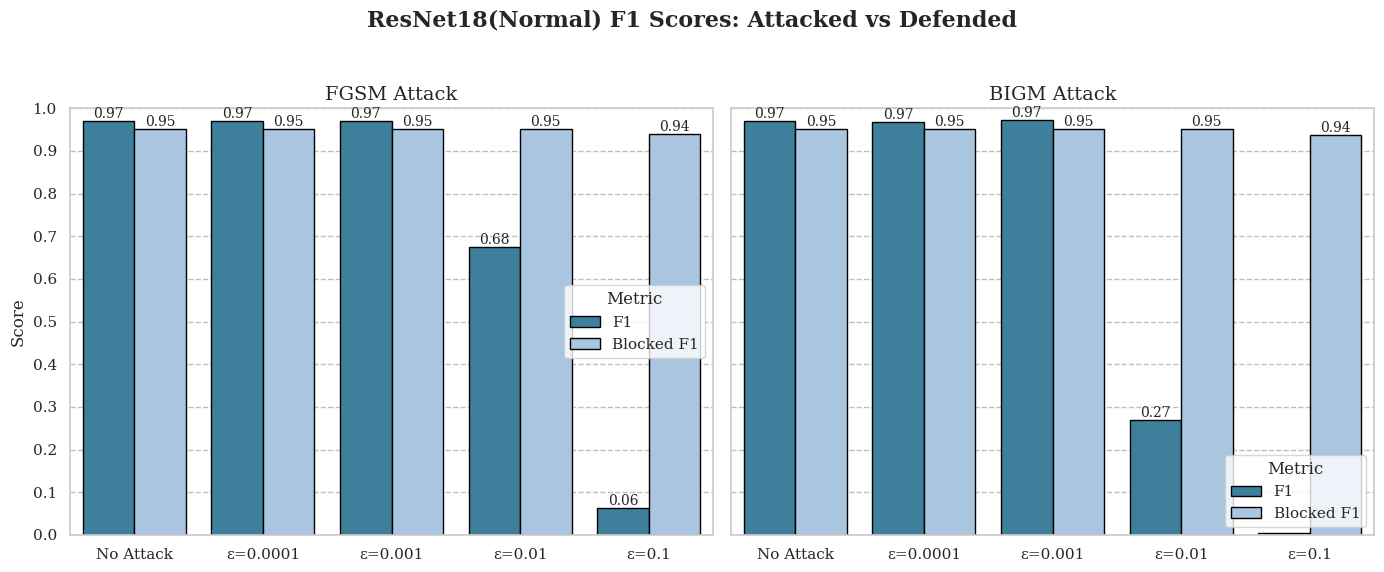

resnet18_normalized_nosampling


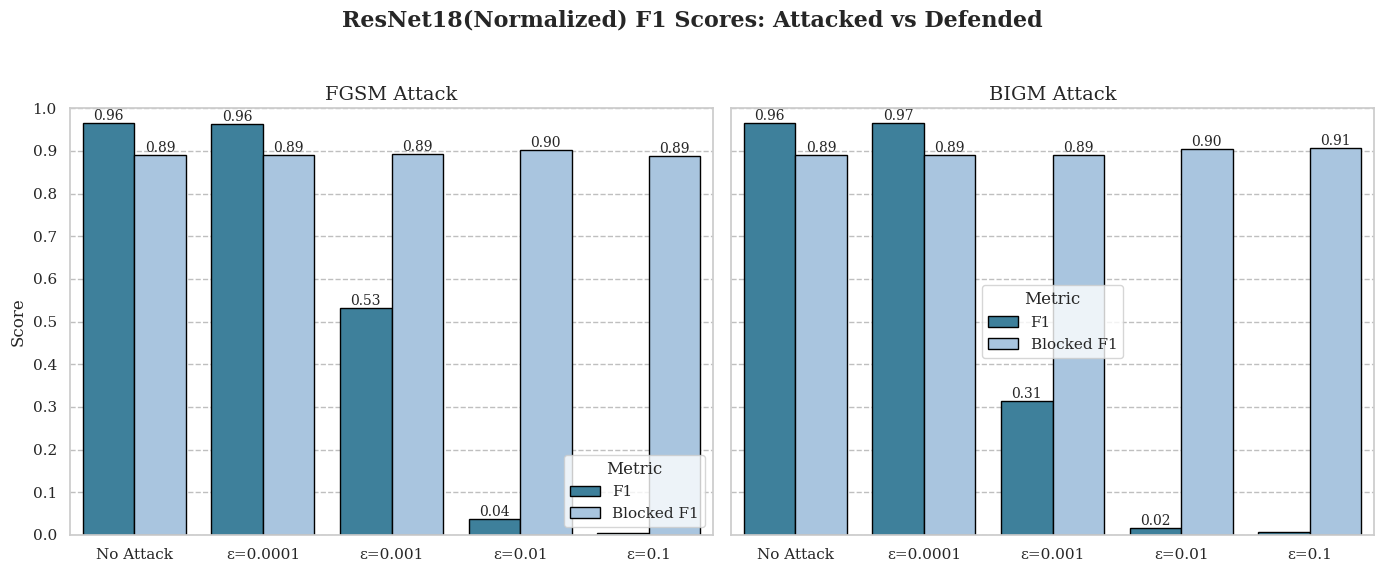

In [109]:
for model_name in df.model.unique():
    print(model_name)
    ndf = df.query('model==@model_name')
    backbone = 'ResNet18' if 'resnet' in model_name else 'MobileNetV3L'
    data_type = 'Normalized' if 'normalized' in model_name.lower() else 'Normal'
    title_name = f'{backbone}({data_type})'
    plot_groupped_bars(ndf, title=f'{title_name} F1 Scores: Attacked vs Defended',save_as=save_dir/f'{model_name}.pdf')

## Model Parameters

In [43]:
import os
import sys

sys.path.append(r"C:\Users\Viper\Desktop\thesis_code\results\autoencoder")
import torch
import json


models = [
    f
    for f in Path(r"C:\Users\Viper\Desktop\thesis_code\results\autoencoder").rglob(
        "best_model_full.pth*"
    )
]

model_params = {}

for model in models:
    try:
        model_name = model.parent.name.lower()
        print(model_name)
        # model_name = (
        #     "rdunet"
        #     if "rdunet" in model_name
        #     else (
        #         "unet"
        #         if "unet" in model_name
        #         else (
        #             "resnet18"
        #             if "resnet" in model_name
        #             else "mobilenetv3l" if "mobilenet" in model_name else ""
        #         )
        #     )
        # )

        model = torch.load(model, map_location="cpu", weights_only=False)
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        model_params[model_name] = total_params
        print(f"Total trainable parameters {model_name}: {total_params}")
    except Exception as e:
        print(f"Error processing model {model}: {e}")
        pass

epoch_times = {}

print(model_params)

rdunet_normal
Error processing model C:\Users\Viper\Desktop\thesis_code\results\autoencoder\rdunet_normal\best_model_full.pth: PytorchStreamReader failed reading zip archive: failed finding central directory
rdunet_normalized
Error processing model C:\Users\Viper\Desktop\thesis_code\results\autoencoder\rdunet_normalized\best_model_full.pth: PytorchStreamReader failed reading zip archive: failed finding central directory
rdunet_normalized_no_clf
Error processing model C:\Users\Viper\Desktop\thesis_code\results\autoencoder\rdunet_normalized_no_clf\best_model_full.pth: PytorchStreamReader failed reading zip archive: failed finding central directory
rdunet_normal_no_clf
Error processing model C:\Users\Viper\Desktop\thesis_code\results\autoencoder\rdunet_normal_no_clf\best_model_full.pth: PytorchStreamReader failed reading zip archive: failed finding central directory
unet_custom_normal
Error processing model C:\Users\Viper\Desktop\thesis_code\results\autoencoder\unet_custom_normal\best_mod

In [16]:
from collections import defaultdict
import re
from pathlib import Path
import pandas as pd
import numpy as np

log_files = [f for f in Path("../results/").rglob("*/trainer.log")]
print(f"Found {len(log_files)}")
# Pattern to extract the learning rate
pattern = re.compile(r"Learning rate:\s*([0-9.eE-]+)")
learning_rates = defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    model_name = logfile.parent.name
    model_type = logfile.parent.parent.name
    if model_type not in ["image_classification", "autoencoder"]:
        continue
    if "adv" in model_name or "no_clf" in model_name:
        continue
    if "mobile" in model_name and "image_classification" != logfile.parent.parent.name:
        continue
    model_name = (
        "rdunet"
        if "rdunet" in model_name
        else (
            "unet"
            if "unet" in model_name
            else (
                "resnet18"
                if "resnet" in model_name
                else "mobilenetv3l" if "mobilenet" in model_name else ""
            )
        )
    )
    if model_name == "":
        continue
    # print(model_name, logfile)
    with open(logfile, "r") as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split("|")[0])
    end_time = pd.to_datetime(lines[-1].split("|")[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[model_name].append(lr)

    # compute avg seconds per epoch
    try:
        num_epochs = len(learning_rates[model_name])
        total_seconds = (end_time - start_time).total_seconds()
        epoch_seconds[model_name] = total_seconds / num_epochs
        print(
            f"Model: {model_name}, Total time: {total_seconds:.2f} seconds, "
            f"Epochs: {num_epochs}, Avg seconds per epoch: {epoch_seconds[model_name]:.2f}"
        )
    except:
        pass
epoch_seconds

Found 36
Model: rdunet, Total time: 43993.61 seconds, Epochs: 381, Avg seconds per epoch: 115.47
Model: rdunet, Total time: 36380.62 seconds, Epochs: 694, Avg seconds per epoch: 52.42
Model: unet, Total time: 221.29 seconds, Epochs: 4, Avg seconds per epoch: 55.32
Model: unet, Total time: 222.32 seconds, Epochs: 8, Avg seconds per epoch: 27.79
Model: mobilenetv3l, Total time: 85745.66 seconds, Epochs: 47, Avg seconds per epoch: 1824.38
Model: mobilenetv3l, Total time: 84684.91 seconds, Epochs: 90, Avg seconds per epoch: 940.94
Model: resnet18, Total time: 85279.09 seconds, Epochs: 44, Avg seconds per epoch: 1938.16
Model: resnet18, Total time: 86229.39 seconds, Epochs: 87, Avg seconds per epoch: 991.14


{'rdunet': 52.42164349855908,
 'unet': 27.789817125,
 'mobilenetv3l': 940.9434169222222,
 'resnet18': 991.1423565402298}

In [17]:
d1 = epoch_seconds

d2 = model_params

samples_per_epoch = {
    "mobilenetv3l": 28881 + 9627,
    "resnet18": 28881 + 9627,
    "unet": 1500 + 1500,
    "rdunet": 1500 + 1500,
}
sorted_keys = sorted(d1.keys())
sorted_keys = [k for k in sorted_keys if "res" not in k]
vals1 = [d1[k] / samples_per_epoch[k] for k in sorted_keys]
vals2 = [d2[k] for k in sorted_keys]


x = np.arange(len(sorted_keys))

width = 0.35


fig, ax1 = plt.subplots(figsize=(8, 5))

bars1 = ax1.bar(x - width / 2, vals1, width, label="Run 1")

ax1.set_ylabel("Seconds per Sample", fontsize=15)
ax1.set_xticks(x)

ax1.set_xticklabels(sorted_keys, fontsize=12)

ax1.set_xlabel("Model", fontsize=15)

# ax1.set_title('Grouped Barplot by Model')

ax1.grid(True, axis="y", linestyle="--", alpha=0.7)


# Second y-axis (identical style)

ax2 = ax1.twinx()

bars2 = ax2.bar(x + width / 2, vals2, width, label="Run 2", color="orange")

ax2.set_ylabel("Model Parameters", fontsize=15)


fig.tight_layout()

ax2.legend(
    [bars1, bars2],
    ["Approx. Seconds Per Sample", "Model Parameters"],
    loc="upper right",
)

plt.savefig("sample_sec_params.pdf")

plt.show()

KeyError: 'rdunet'

## From CSV

### Attack Clf

In [20]:
import pandas as pd
from pathlib import Path

In [21]:
image_clf_path = Path("../results/image_classification")
metrics_files = [f for f in image_clf_path.rglob("*.csv") if "adv" not in str(f)]
log_files = [f for f in image_clf_path.rglob("*.log") if "adv" not in str(f)]
metrics_files, log_files

([WindowsPath('../results/image_classification/bigger_cnn2d/metrics.csv'),
  WindowsPath('../results/image_classification/bigger_cnn2d_normalized/metrics.csv'),
  WindowsPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling/metrics.csv'),
  WindowsPath('../results/image_classification/mobilenet_v3_large_nosampling/metrics.csv'),
  WindowsPath('../results/image_classification/resnet18_normalized_nosampling/metrics.csv'),
  WindowsPath('../results/image_classification/resnet18_nosampling/metrics.csv'),
  WindowsPath('../results/image_classification/simple_cnn/metrics.csv'),
  WindowsPath('../results/image_classification/simple_cnn_normalized/metrics.csv')],
 [WindowsPath('../results/image_classification/bigger_cnn2d/trainer.2025-06-22_17-16-21_051239.log'),
  WindowsPath('../results/image_classification/bigger_cnn2d/trainer.2025-06-23_17-17-11_849421.log'),
  WindowsPath('../results/image_classification/bigger_cnn2d/trainer.2025-06-24_18-25-53_374931.log'),
  Win

..\results\image_classification\mobilenet_v3_large_normalized_nosampling\metrics.csv
..\results\image_classification\mobilenet_v3_large_nosampling\metrics.csv


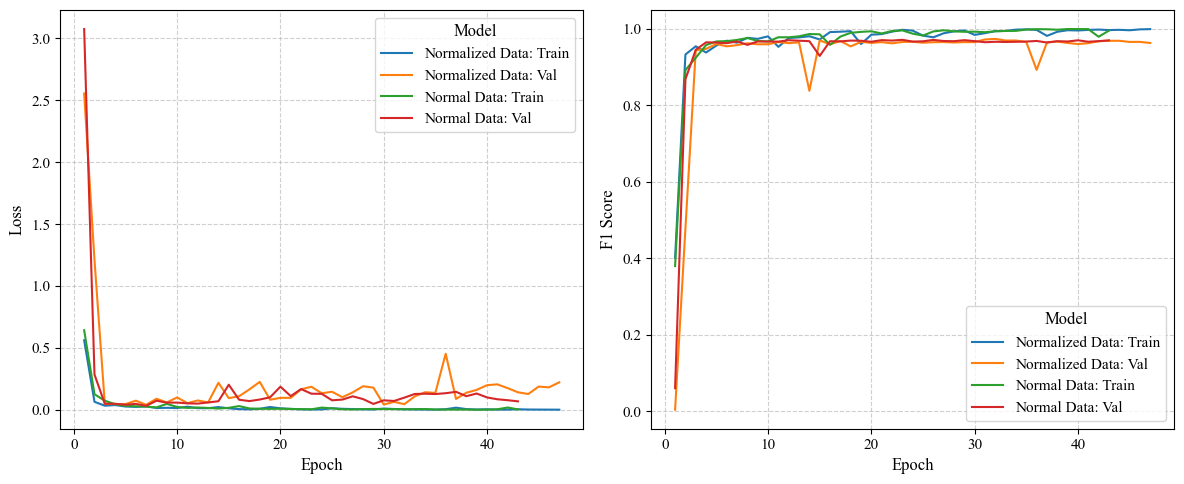

In [71]:
data_type = "normalized"
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot each file's metrics
for filepath in metrics_files:
    if "mobile" not in str(filepath).lower() or "adv" in str(filepath).lower():
        continue
    label = "ResNet18" if "resnet" in str(filepath).lower() else "MobileNetV3"

    print(filepath)
    if data_type in str(filepath).lower():
        label = label + " (normalized data)"
        label = "Normalized Data"
    else:
        label = "Normal Data"

    df = pd.read_csv(filepath)
    axs[0].plot(df["epoch"], df["train_loss"], label=label + ": Train")
    axs[0].plot(df["epoch"], df["val_loss"], label=label + ": Val")
    axs[1].plot(df["epoch"], df["f1_score"], label=label + ": Train")
    axs[1].plot(df["epoch"], df["val_f1_score"], label=label + ": Val")

# Academic plot styling
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
# axs[0].set_title('Validation Loss over Epochs')
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend(title="Model")

axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("F1 Score")
# axs[1].set_title('Validation F1 Score over Epochs')
axs[1].grid(True, linestyle="--", alpha=0.6)
axs[1].legend(title="Model")
plt.savefig("val_loss_f1_atk_clf.pdf")
plt.tight_layout()
plt.show()

{'mobilenet_v3_large_normalized_nosampling': 1824.3756706595743, 'mobilenet_v3_large_nosampling': 1969.416454023256}


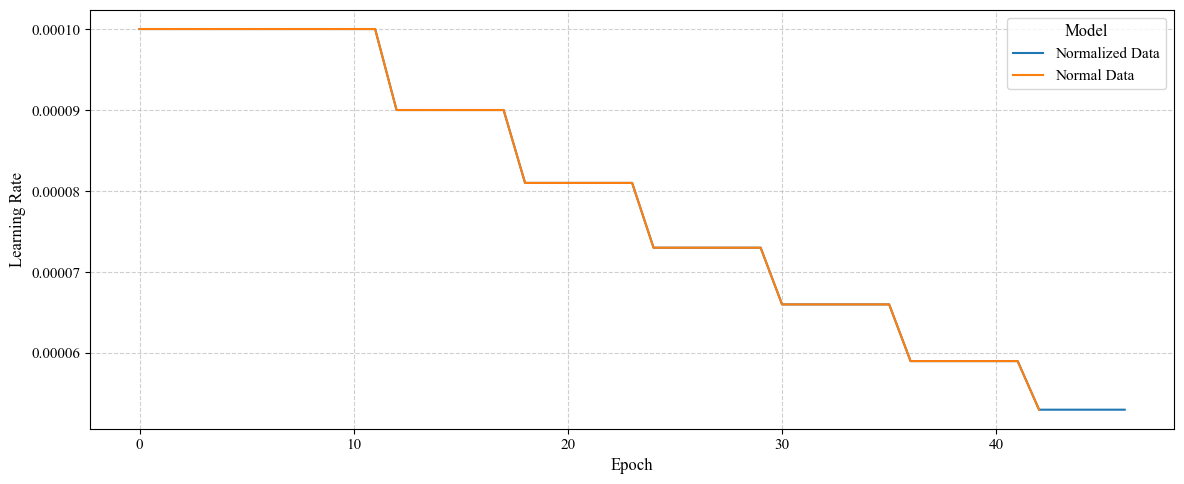

In [72]:
from collections import defaultdict
import re

# Pattern to extract the learning rate
pattern = re.compile(r"Learning rate:\s*([0-9.eE-]+)")
learning_rates = defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    if "mobile" not in str(logfile).lower() or "adv" in str(logfile).lower():
        continue
    with open(logfile, "r") as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split("|")[0])
    end_time = pd.to_datetime(lines[-1].split("|")[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)
data_type = "normalized"
fig = plt.figure(figsize=(12, 5))

for log_file, lrs in learning_rates.items():
    label = "ResNet18" if "resnet" in str(log_file).lower() else "MobileNetV3"
    if data_type in str(log_file).lower():
        label = label + "_normalized"
        label = "Normalized Data"
    else:
        label = "Normal Data"

    epochs = list(range(len(lrs)))

    plt.plot(epochs, lrs, label=label)

# Academic plot styling
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Model")
plt.savefig("lr_per_epoch_atk_clf.pdf")
plt.tight_layout()
plt.show()

#### Training Time

### Adversarial Training

In [73]:
metrics_files = [f for f in image_clf_path.rglob("*.csv") if "adv" in str(f)]
log_files = [f for f in image_clf_path.rglob("*.log") if "adv" in str(f)]
metrics_files, log_files

([WindowsPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling_adv/metrics.csv'),
  WindowsPath('../results/image_classification/mobilenet_v3_large_nosampling_adv/metrics.csv'),
  WindowsPath('../results/image_classification/resnet18_normalized_nosampling_adv/metrics.csv'),
  WindowsPath('../results/image_classification/resnet18_nosampling_adv/metrics.csv')],
 [WindowsPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling_adv/trainer.log'),
  WindowsPath('../results/image_classification/mobilenet_v3_large_nosampling_adv/trainer.log'),
  WindowsPath('../results/image_classification/resnet18_normalized_nosampling_adv/trainer.log'),
  WindowsPath('../results/image_classification/resnet18_nosampling_adv/trainer.log')])

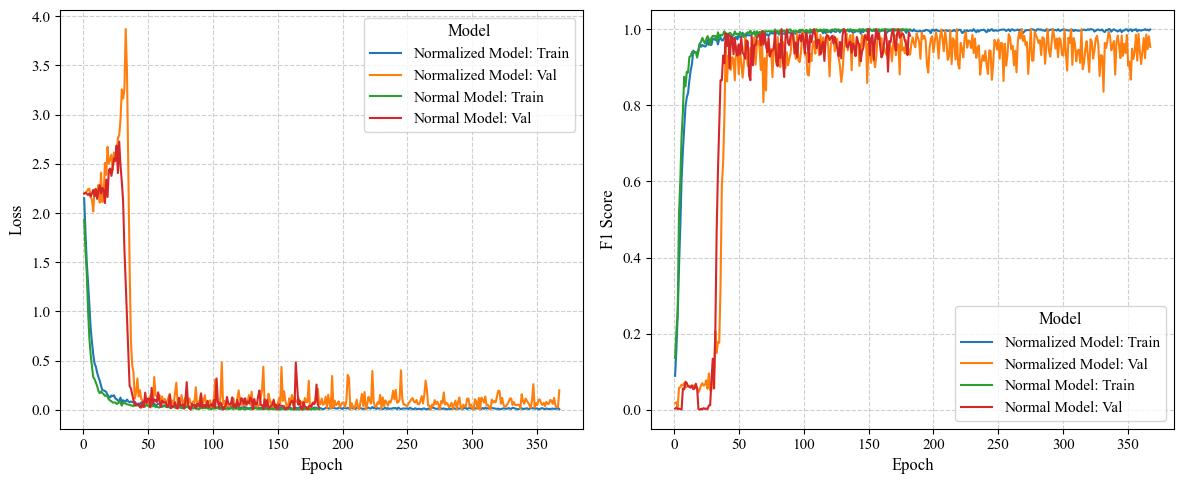

{'mobilenet_v3_large_normalized_nosampling_adv': 187.2548554076087, 'mobilenet_v3_large_nosampling_adv': 217.38612083606557}


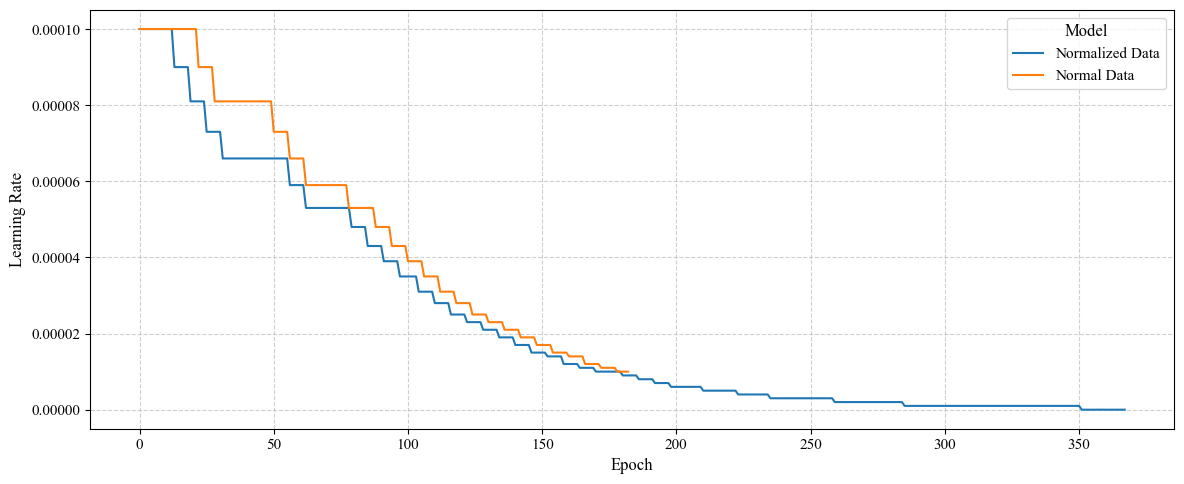

In [75]:
from collections import defaultdict
import re

# Pattern to extract the learning rate
pattern = re.compile(r"Learning rate:\s*([0-9.eE-]+)")
learning_rates = defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    if "mobile" not in str(logfile).lower() or "adv" not in str(logfile).lower():
        continue
    with open(logfile, "r") as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split("|")[0])
    end_time = pd.to_datetime(lines[-1].split("|")[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)

data_type = "normalized"
fig = plt.figure(figsize=(12, 5))

for log_file, lrs in learning_rates.items():
    label = "ResNet18" if "resnet" in str(log_file).lower() else "MobileNetV3"
    if data_type in str(log_file).lower():
        label = label + "_normalized"
        label = "Normalized Data"
    else:
        label = "Normal Data"

    epochs = list(range(len(lrs)))

    plt.plot(epochs, lrs, label=label)

# Academic plot styling
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Model")
plt.savefig("lr_per_epoch_atk_clf_adv.pdf")
plt.tight_layout()
plt.show()

### Adversarial Blocking Models

In [76]:
ae_path = Path("../results/autoencoder")
metrics_files = [f for f in ae_path.rglob("*.csv")]
log_files = [f for f in ae_path.rglob("*.log")]
metrics_files, log_files

([], [])

C:\Users\Viper\AppData\Local\Temp\ipykernel_7104\808132855.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(title="Model")
C:\Users\Viper\AppData\Local\Temp\ipykernel_7104\808132855.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(title="Model")


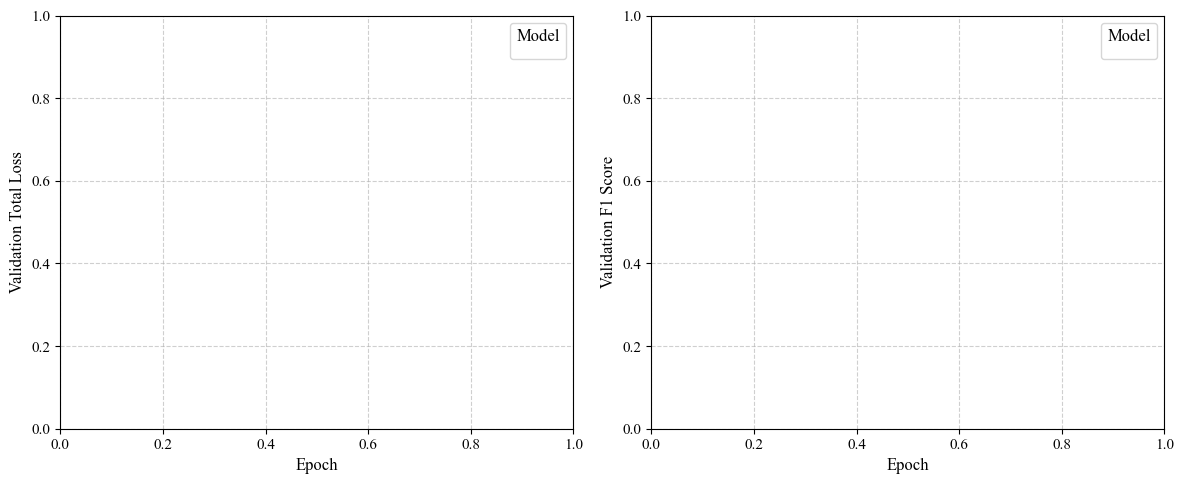

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot each file's metrics
for filepath in metrics_files:
    df = pd.read_csv(filepath)
    label = "rdunet" if "rdunet" in str(filepath) else "unet"
    label = label + "_normalized" if "normalized" in str(filepath) else label
    axs[0].plot(df["epoch"], df["val_total_loss"], label=label)
    axs[1].plot(df["epoch"], df["val_rec_f1"], label=label)

# Academic plot styling
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Validation Total Loss")
# axs[0].set_title('Validation Total Loss over Epochs')
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend(title="Model")

axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Validation F1 Score")
# axs[1].set_title('Validation F1 Score over Epochs')
axs[1].grid(True, linestyle="--", alpha=0.6)
axs[1].legend(title="Model")
plt.savefig("val_loss_f1_ae.pdf")
plt.tight_layout()
plt.show()

{'rdunet_normalized': 114.91395406272402, 'rdunet_normal': 129.44098082020201, 'unet_custom_normal': 58.3235134057971, 'unet_custom_normalized': 55.87271781586402}


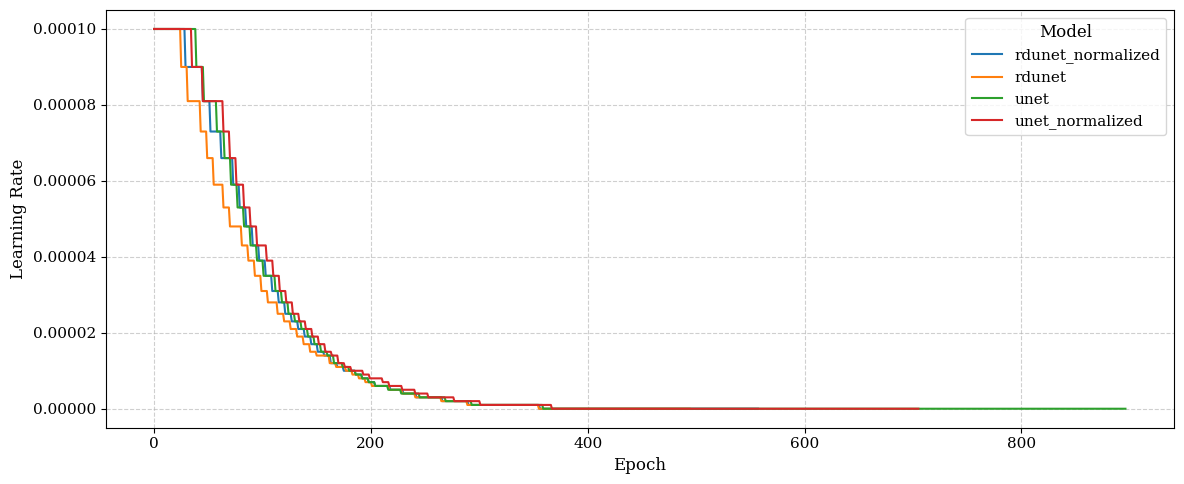

In [385]:
from collections import defaultdict
import re
# Pattern to extract the learning rate
pattern = re.compile(r'Learning rate:\s*([0-9.eE-]+)')
learning_rates=defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    with open(logfile, 'r') as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split('|')[0])
    end_time = pd.to_datetime(lines[-1].split('|')[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)

data_type='normalized'
fig = plt.figure(figsize=(12, 5))

for filepath, lrs in learning_rates.items():    
    label = 'rdunet' if 'rdunet' in str(filepath) else 'unet'
    label = label+'_normalized' if 'normalized' in str(filepath) else label
    
    epochs = list(range(len(lrs)))
    
    plt.plot(epochs, lrs,  label=label)

# Academic plot styling
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.savefig('lr_per_epoch_ae.pdf')
plt.tight_layout()
plt.show()

### Evaluation Results

In [22]:
from pathlib import Path

eval_model_type = "binary"
suffix = "_mobnet_non_guided_ae"
eval_dir = Path("../results/adversarial_blocking_binary")

eval_model_type = "atk_clf"  # binary, atk_clf
suffix = "_mobnet_non_guided_ae"
eval_dir = Path("../results/adversarial_blocking_attack")

# eval_model_type = "clf"  # binary, atk_clf
# suffix = "_mobnet_non_guided_ae"
# eval_dir = Path("../results/adversarial_blocking_mobnet")

# eval_model_type = "clf"  # binary, atk_clf
# suffix = "_mobnet_guided_ae"
# eval_dir = Path("../results/adversarial_blocking")


out_dir = Path(eval_model_type + suffix)

if not out_dir.exists():
    out_dir.mkdir(parents=True, exist_ok=True)

csv_files = [f for f in eval_dir.rglob("*.csv")]
normal_csv_files = [f for f in csv_files if "normalized" not in str(f)]
normalized_csv_files = [f for f in csv_files if "normalized" in str(f)]

normal_csv_files, normalized_csv_files

([WindowsPath('../results/adversarial_blocking_attack/mobilenet_v3_large_nosampling/evaluation_results_normal_val.csv')],
 [WindowsPath('../results/adversarial_blocking_attack/mobilenet_v3_large_normalized_nosampling/evaluation_results_normalized_val.csv')])

#### In single Plot

Processing attack: FGSM


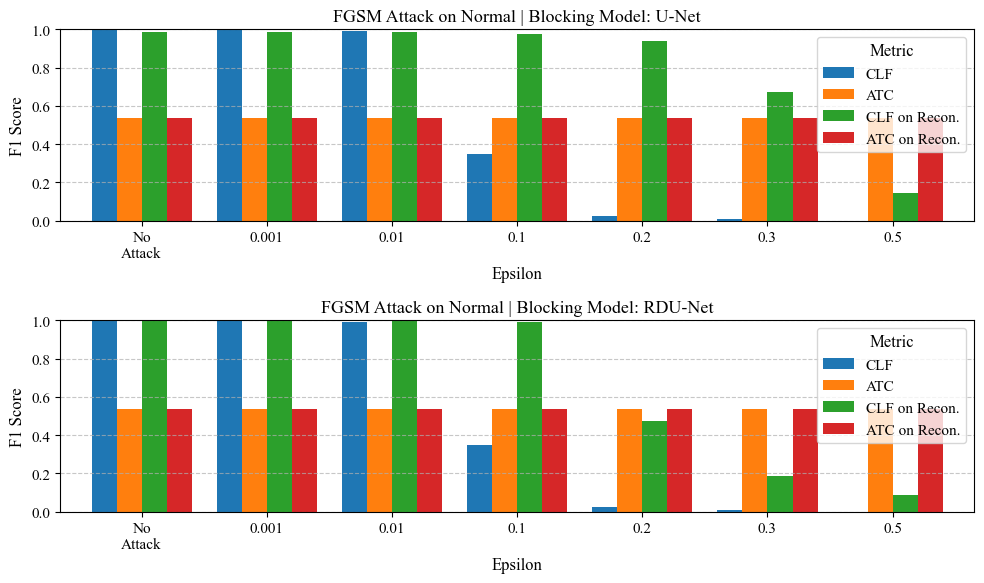

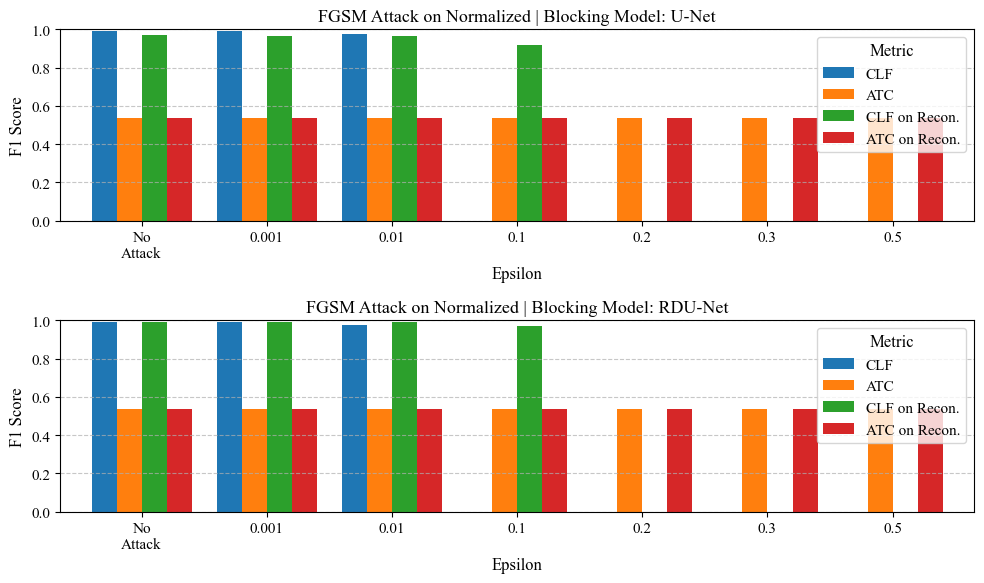

Processing attack: BIGM


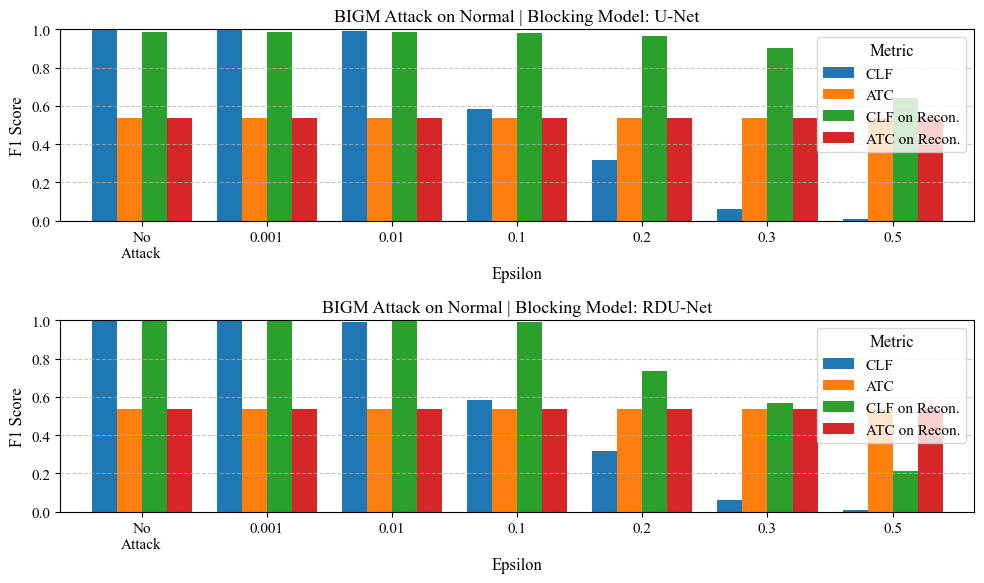

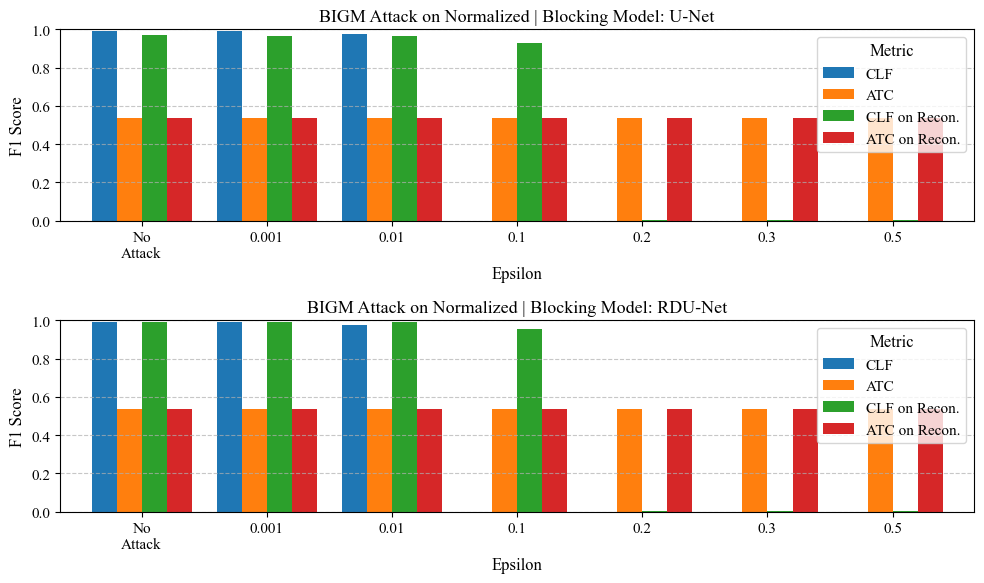

Processing attack: MIM


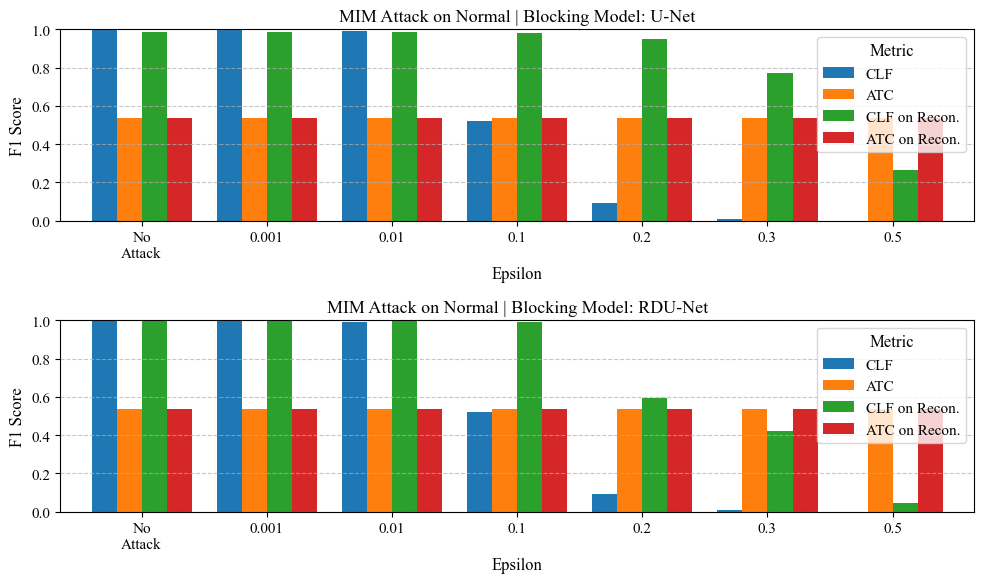

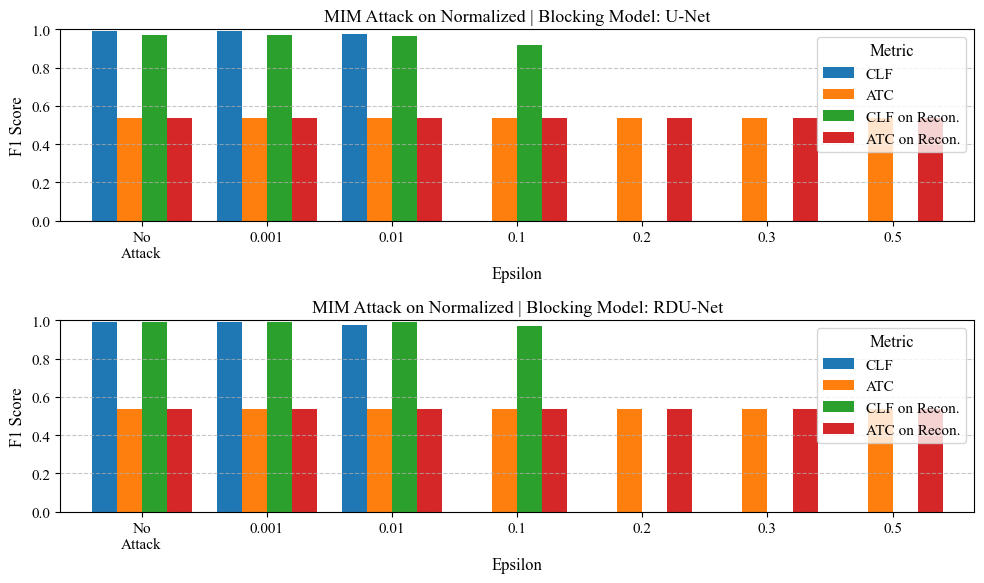

Processing attack: FGSM


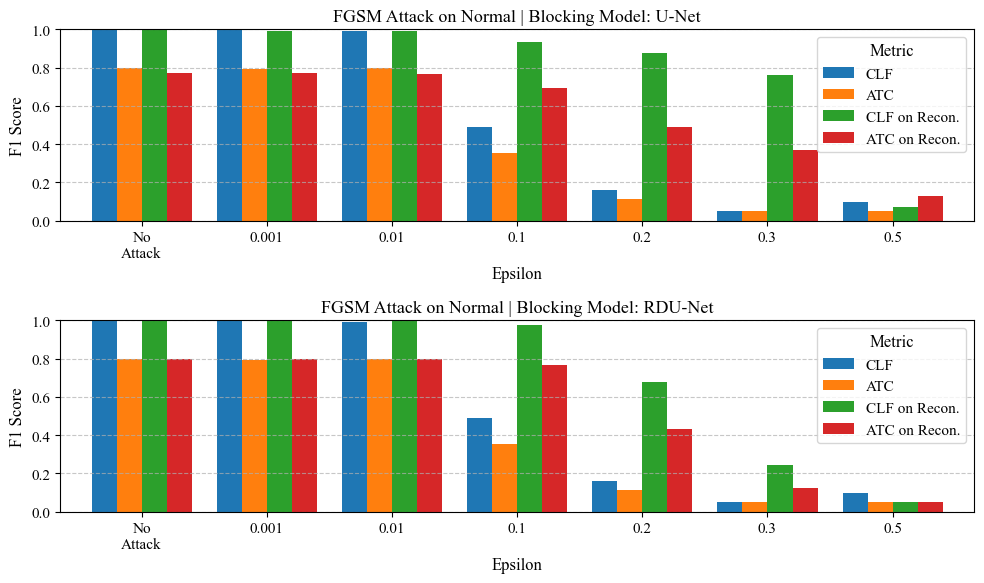

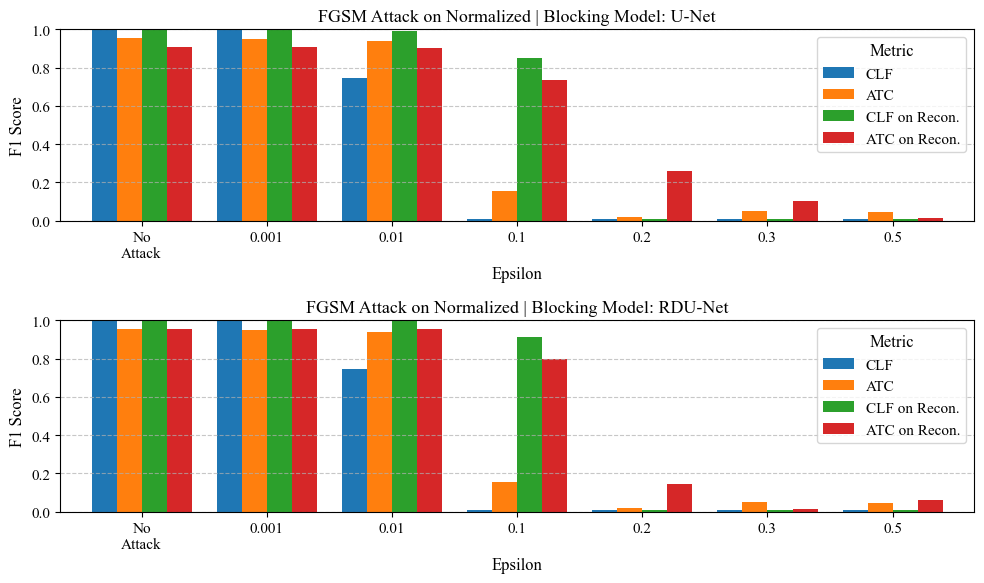

Processing attack: BIGM


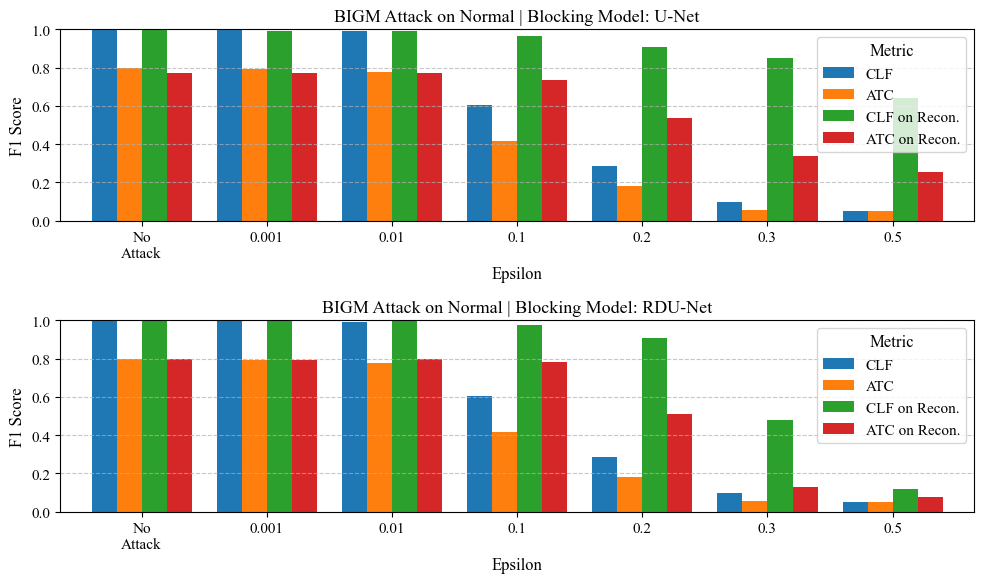

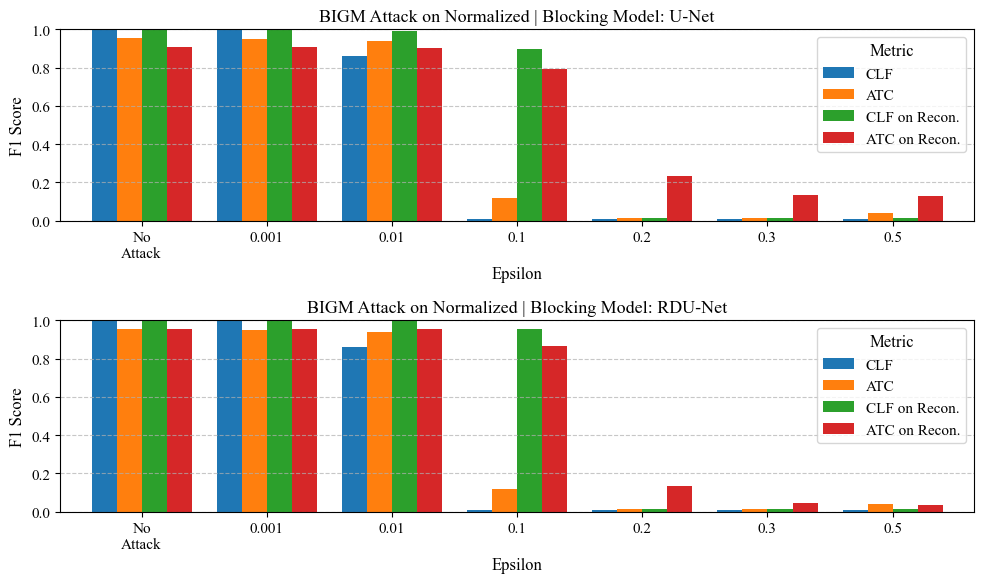

Processing attack: MIM


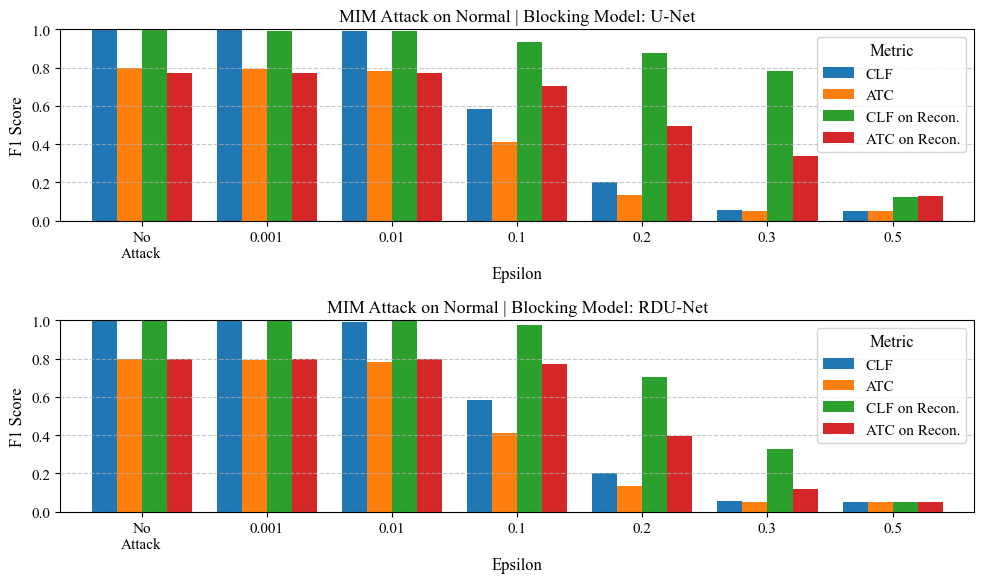

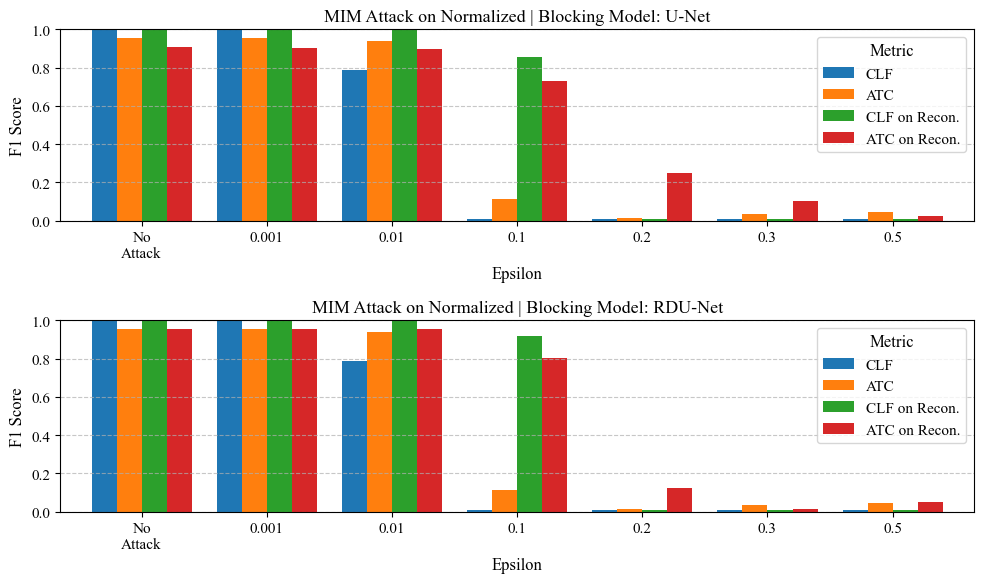

Processing attack: FGSM


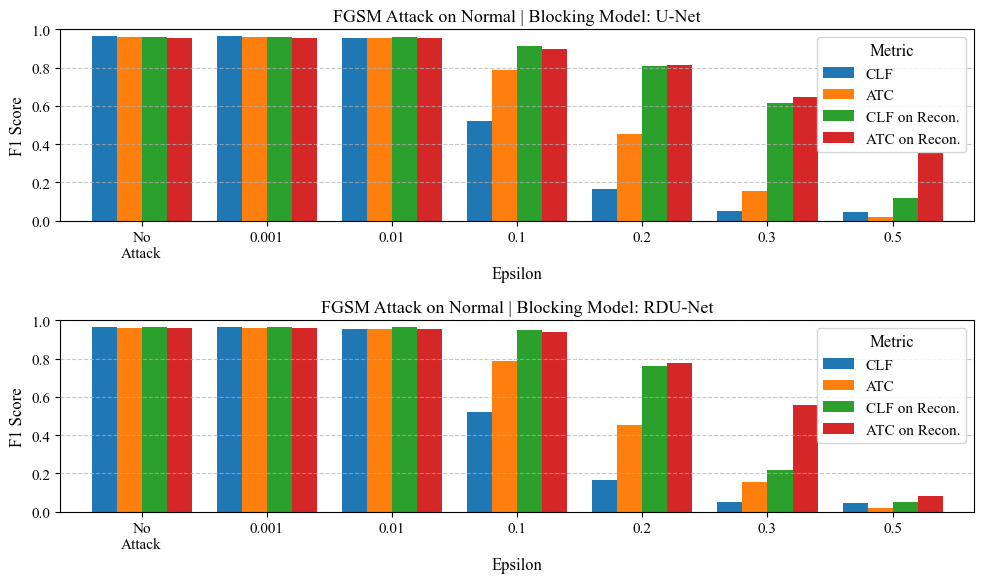

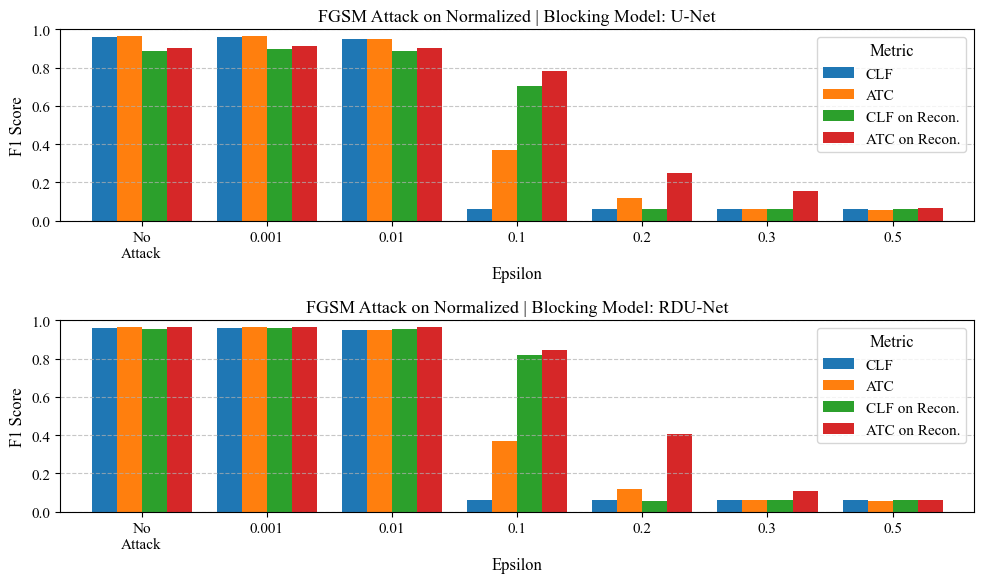

Processing attack: BIGM


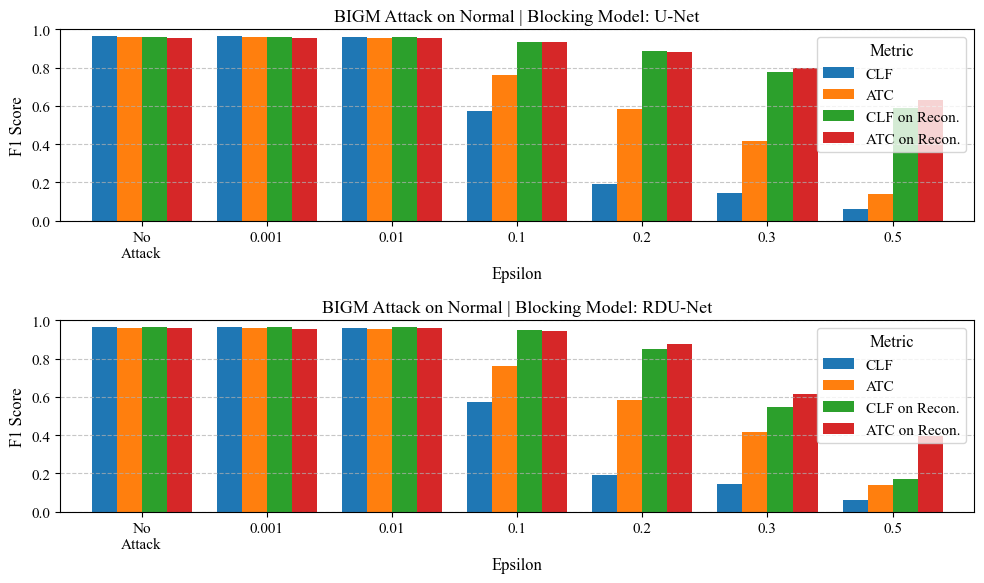

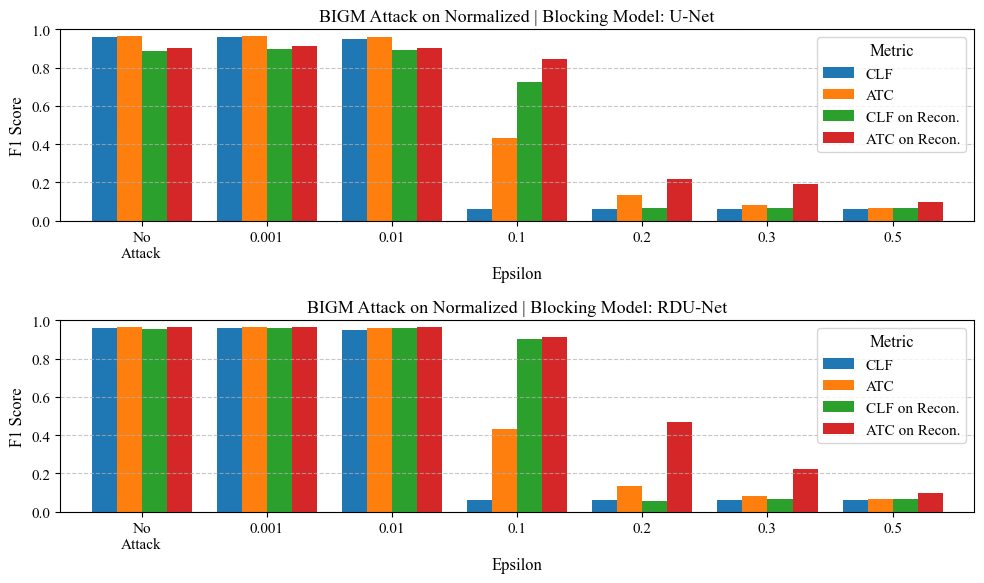

Processing attack: MIM


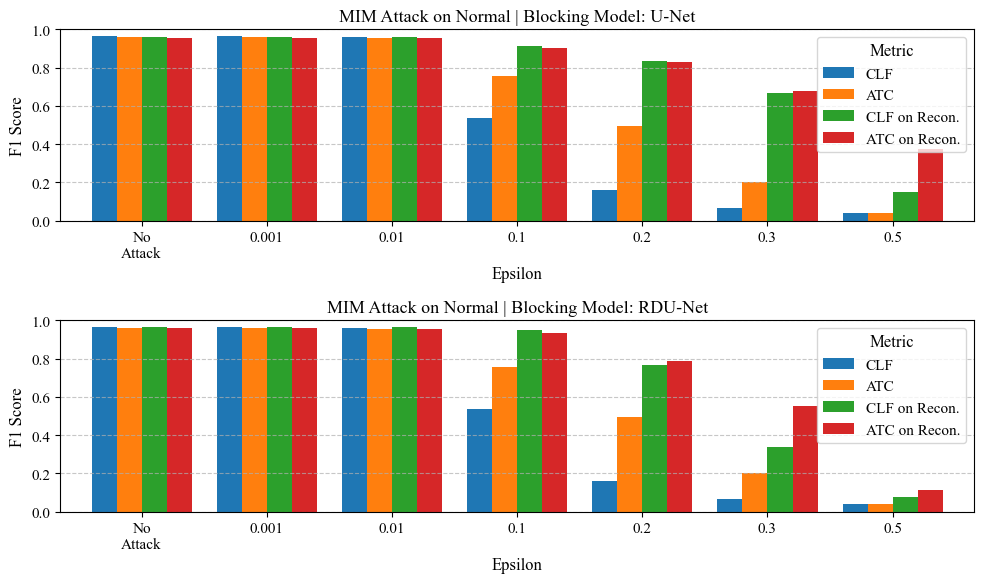

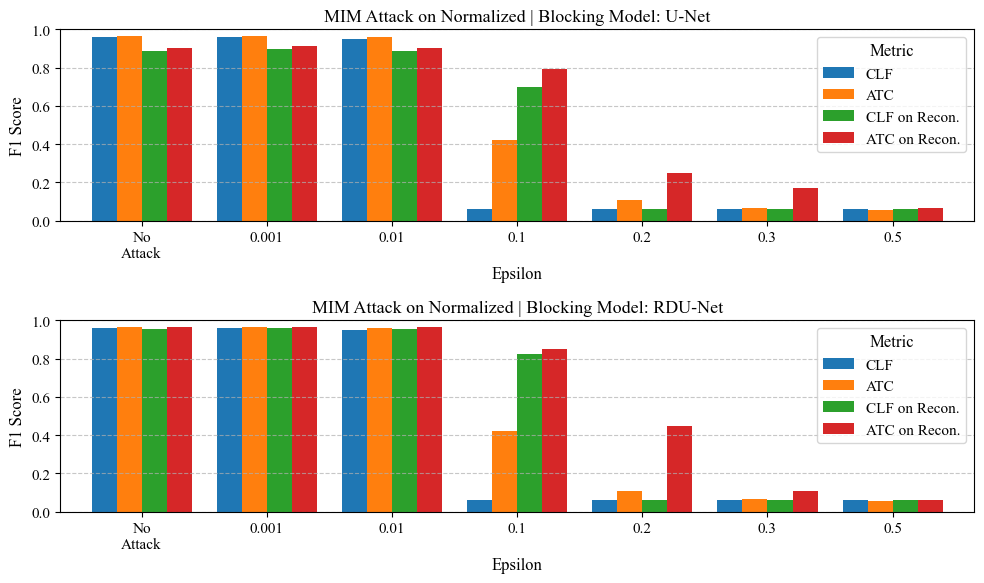

Processing attack: FGSM


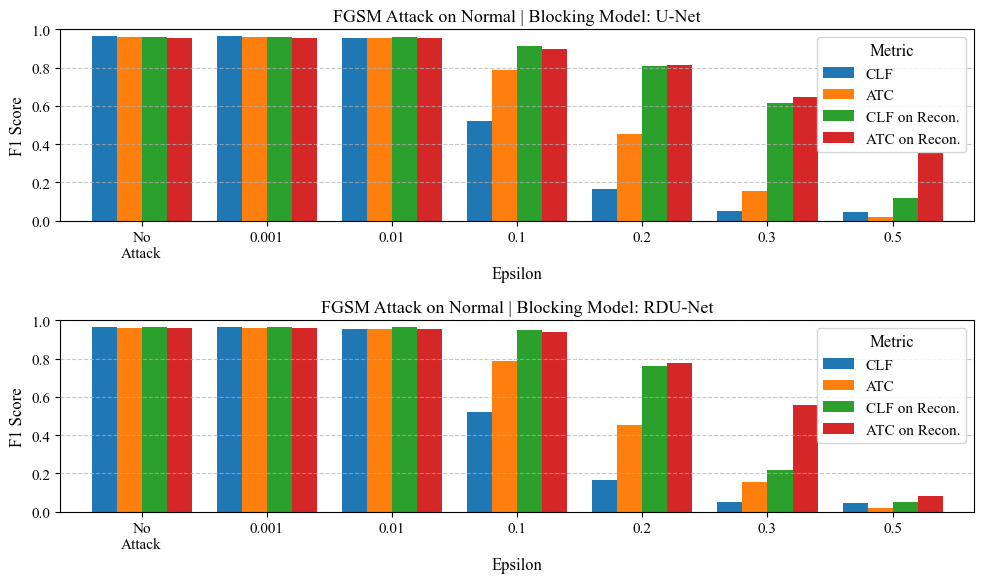

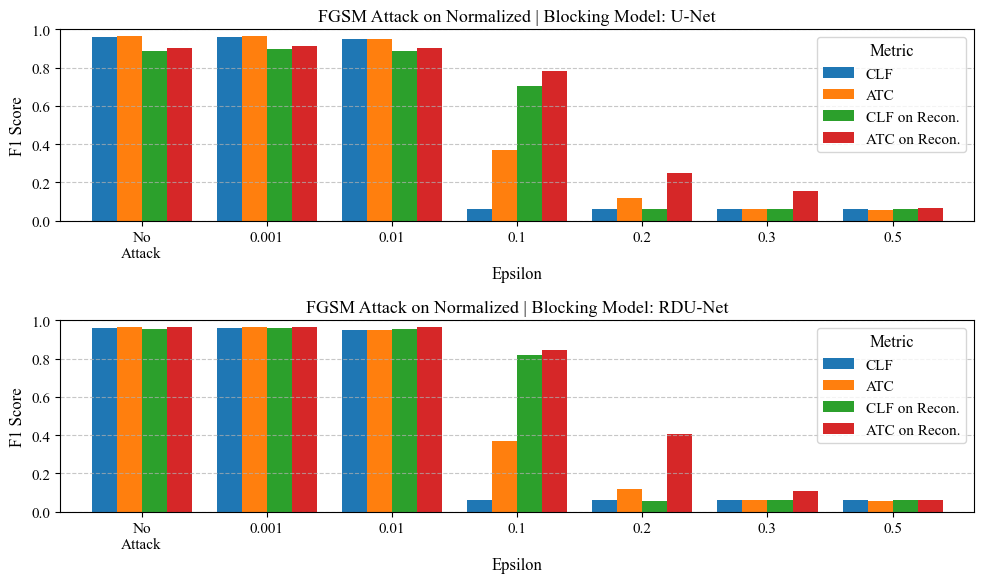

Processing attack: BIGM


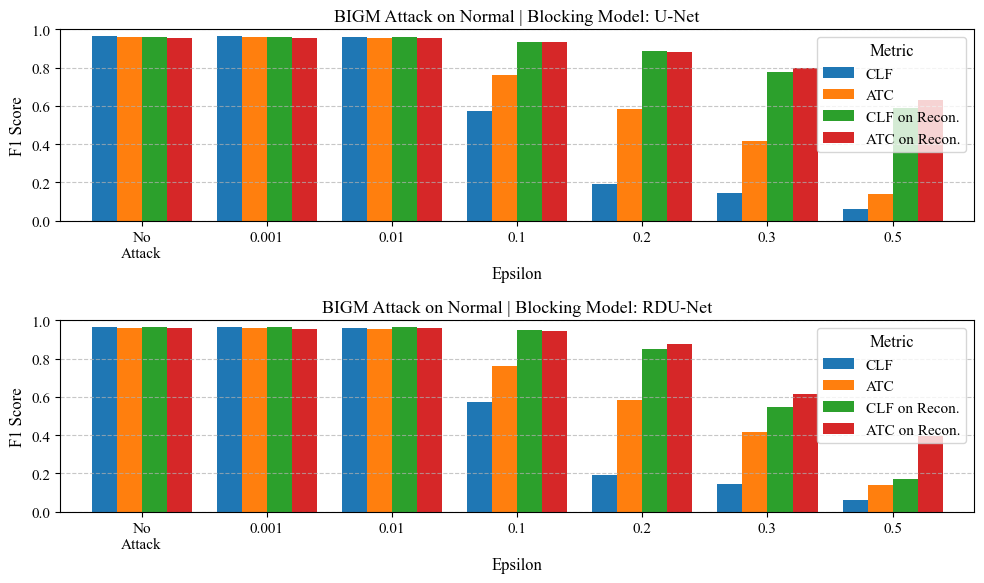

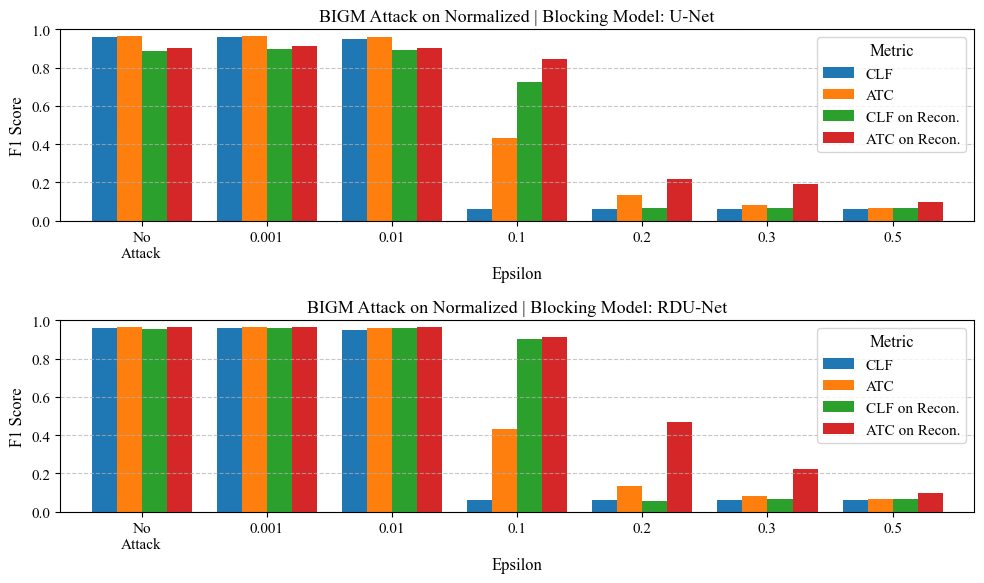

Processing attack: MIM


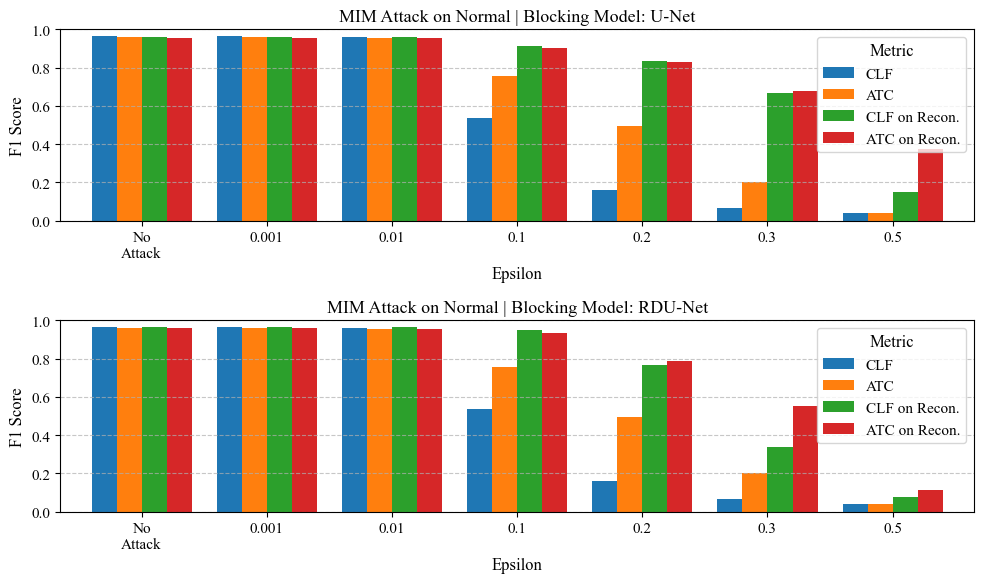

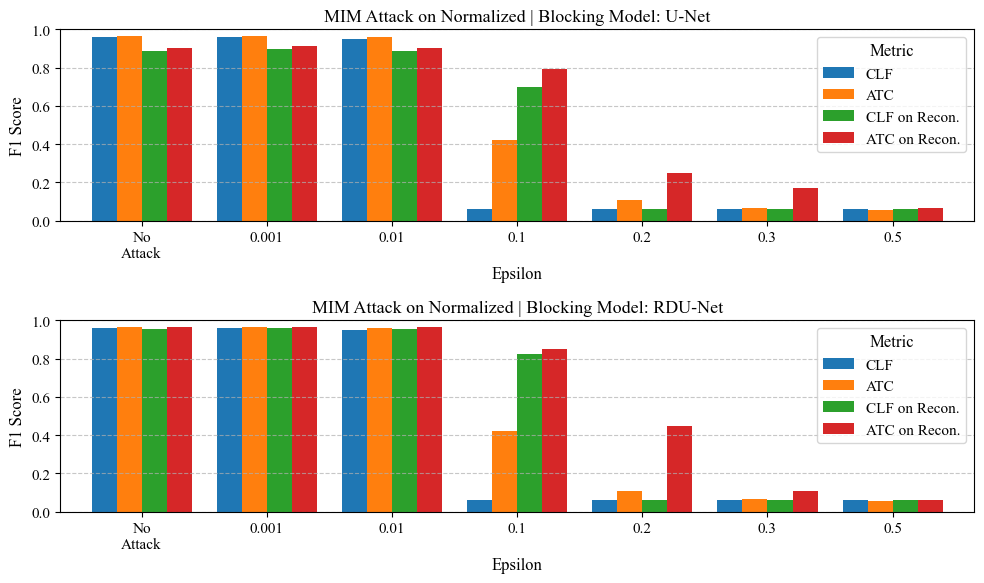

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


def refine_adv_name(name):
    atk_name = ""
    eps = 0
    if "fast" in name.lower():
        atk_name = "FGSM"
    elif "basic" in name.lower():
        atk_name = "BIGM"
    elif "mom" in name.lower():
        atk_name = "MIM"
    if "eps" in name.lower():
        eps = float(name.split("eps_")[-1])
    return atk_name, eps


eval_model_type = "binary"
suffix = "_mobnet_non_guided_ae"
eval_dir = Path("../results/adversarial_blocking_binary")

eval_model_type = "atk_clf"  # binary, atk_clf
suffix = "_mobnet_non_guided_ae"
eval_dir = Path("../results/adversarial_blocking_attack")

# eval_model_type = "clf"  # binary, atk_clf
# suffix = "_mobnet_non_guided_ae"
# eval_dir = Path("../results/adversarial_blocking_mobnet")

# eval_model_type = "clf"  # binary, atk_clf
# suffix = "_mobnet_guided_ae"
# eval_dir = Path("../results/adversarial_blocking")

# list of tuples: suffix, eval_dir, model_type
suffix_eval_dir_model_type = [
    ["binary", "../results/adversarial_blocking_binary", "_mobnet_non_guided_ae"],
    ["atk_clf", "../results/adversarial_blocking_attack", "_mobnet_non_guided_ae"],
    ["clf", "../results/adversarial_blocking_mobnet", "_mobnet_non_guided_ae"],
    ["clf", "../results/adversarial_blocking_mobnet", "_mobnet_guided_ae"],
]

for eval_model_type, eval_dir, suffix in suffix_eval_dir_model_type:
    eval_dir = Path(eval_dir)
    out_dir = Path(eval_model_type + suffix)

    if not out_dir.exists():
        out_dir.mkdir(parents=True, exist_ok=True)

    csv_files = [f for f in eval_dir.rglob("*.csv")]
    normal_csv_files = [f for f in csv_files if "normalized" not in str(f)]
    normalized_csv_files = [f for f in csv_files if "normalized" in str(f)]

    normal_csv_files, normalized_csv_files

    main_model = "MobileNetV3"
    first_bar_name = "No\nAttack"
    first_bar = [
        "clean_clf_f1",
        "clean_atc_f1",
        "recon_clean_clf_f1",
        "recon_clean_atc_f1",
    ]

    other_bars = ["adv_clf_f1", "adv_atc_f1", "recon_adv_clf_f1", "recon_adv_atc_f1"]
    legend_labels = ["CLF", "ATC", "CLF on Recon.", "ATC on Recon."]

    tdf = pd.read_csv(csv_files[0])
    tdf["atk_name"] = tdf["adversarial_name"].apply(lambda x: refine_adv_name(x)[0])
    attack_types = tdf["atk_name"].unique()
    dtype_csv_files = [("normal", f) for f in normal_csv_files] + [
        ("normalized", f) for f in normalized_csv_files
    ]

    for attack in attack_types:
        if attack not in ["FGSM", "BIGM", "MIM"]:
            continue
        print(f"Processing attack: {attack}")
        # list of list[group_name, 4group_data)]

        for data_type, csv_file in dtype_csv_files:
            if "mobile" not in str(csv_file).lower():
                continue
            df = pd.read_csv(csv_file)
            df["eps"] = df.adversarial_name.apply(
                lambda x: float(x.split("eps_")[-1]) if "eps_" in x else 0.0
            )
            df = df.sort_values("eps")
            df["atk_name"] = df["adversarial_name"].apply(
                lambda x: refine_adv_name(x)[0]
            )
            df = df.query("atk_name == @attack")
            curr_data = []
            models = sorted(df.clf_model.unique())
            for clf_model in models:
                clf_model = (
                    "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
                )
                df["clf_model"] = df["clf_model"].apply(
                    lambda x: "ResNet18" if "resnet" in x.lower() else "MobileNetV3"
                )
                # df['ae_model'] = df['ae_model'].apply(lambda x: "unet
                if clf_model != main_model:
                    continue

                for ae_model in df.ae_model.unique():
                    cdf = df[df.ae_model == ae_model]
                    ae_model = "RDU-Net" if "rdunet" in ae_model.lower() else "U-Net"
                    # get first bar data from mean
                    bar = [first_bar_name, ae_model]
                    for barc in first_bar:
                        bar.append(cdf[barc].mean())
                    curr_data.append(bar)

                    for eps in cdf.eps.unique():
                        if eps == 0:
                            continue
                        bar = [f"{eps}", ae_model]
                        for barc in other_bars:
                            bar.append(cdf.query("eps == @eps")[barc].mean())
                        curr_data.append(bar)
            # plot it
            pdf = pd.DataFrame(curr_data, columns=["xname", "ae_model"] + legend_labels)
            ae_models = pdf.ae_model.unique()
            ae_models = sorted(ae_models, reverse=True)

            nrows = len(pdf.ae_model.unique())
            ncols = 1
            fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6))
            for i, ae_model in enumerate(ae_models):
                group = pdf.query("ae_model==@ae_model")
                ax = axs[i] if nrows > 1 else axs
                group.plot(
                    x="xname",
                    y=legend_labels,
                    kind="bar",
                    ax=ax,
                    legend=True,
                    title=f"{attack} Attack on {data_type.capitalize()} | Blocking Model: {ae_model}",
                    rot=0,
                    width=0.8,
                )
                ax.set_ylabel("F1 Score")
                ax.set_xlabel("Epsilon")
                ax.grid(axis="y", linestyle="--", alpha=0.7)
                ax.set_ylim(0, 1.0)
                ax.legend(title="Metric", loc="upper right")
                ax.set_xticks(np.arange(len(group["xname"])))
                ax.set_xticklabels(group["xname"], rotation=0)
            plt.tight_layout()
            plt.savefig(
                out_dir / f"{data_type}_{attack}.pdf", dpi=300, bbox_inches="tight"
            )
            plt.show()

#### Baseline Model

{'MobileNetV3': 0.9660072922706604} {'MobileNetV3': 0.9595518708229063}


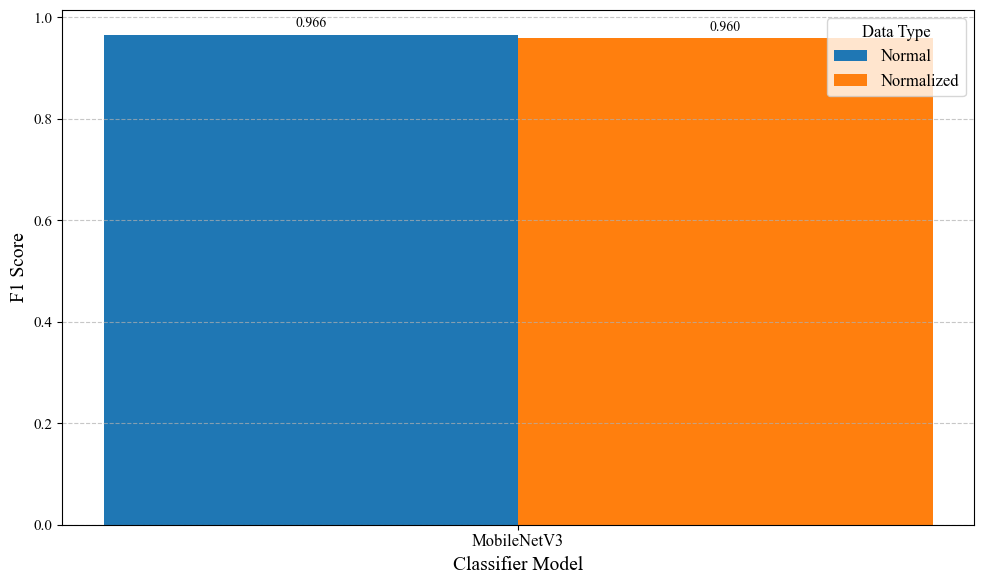

In [25]:
# plot a groupped bar plot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

main_model = "MobileNetV3"

normal_f1_scores = {}
for csv_file in normal_csv_files:
    df = pd.read_csv(csv_file)
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        f1_score = df.query("clf_model==@clf_model").clean_clf_f1.mean()
        clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
        if clf_model != main_model:
            continue
        normal_f1_scores[clf_model] = f1_score
normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    df = pd.read_csv(csv_file)
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        f1_score = df.query("clf_model==@clf_model").clean_clf_f1.mean()
        clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
        if clf_model != main_model:
            continue
        normalized_f1_scores[clf_model] = f1_score


# plot stacked bar plot
labels = list(normal_f1_scores.keys())
normal_scores = [normal_f1_scores[label] for label in labels]
normalized_scores = [normalized_f1_scores[label] for label in labels]
print(normal_f1_scores, normalized_f1_scores)
x_labels = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(
    x_labels - width / 2,
    normal_scores,
    width,
    label="Normal",
)
bars2 = ax.bar(
    x_labels + width / 2,
    normalized_scores,
    width,
    label="Normalized",
)
ax.set_xlabel("Classifier Model", fontsize=14)
ax.set_ylabel("F1 Score", fontsize=14)
# ax.set_title("F1 Scores of Classifier Models", fontsize=16)
ax.set_xticks(x_labels)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(title="Data Type", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
# Annotate bars with F1 scores
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.savefig(out_dir / "f1_scores_mobnet_clf.pdf", dpi=300)
plt.show()

#### Attack on Baseline Models

In [12]:
# plot a groupped bar plot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def refine_adv_name(name):
    atk_name = ""
    eps = 0
    if "fast" in name.lower():
        atk_name = "FGSM"
    elif "basic" in name.lower():
        atk_name = "BIGM"
    elif "mom" in name.lower():
        atk_name = "MIM"
    if "eps" in name.lower():
        eps = float(name.split("eps_")[-1])
    return atk_name, eps


attack_model = "resnet18"  # 'mobilenet'
attack_model = "mobilenet"
atk_gen = "ResNet18" if "resnet" in attack_model else "MobileNetV3"
# adversarial_generator
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    print(csv_file)
    adversarial_generator = "ResNet18" if "resnet" in str(csv_file) else "MobileNetV3L"
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    print(models)

    for clf_model in models:
        # f1_score = df.query("clf_model==@clf_model").clean_clf_f1.mean()
        # clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
        # normal_f1_scores[clf_model] = f1_score
        adv_clf_f1 = (
            df.query("clf_model==@clf_model")
            .groupby("adversarial_name")
            .adv_clf_f1.mean()
            .to_dict()
        )
        for atk_eps, f1_score in adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue

            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    print(csv_file)
    adversarial_generator = "ResNet18" if "resnet" in str(csv_file) else "MobileNetV3L"
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    print(models)
    for clf_model in models:
        # f1_score = df.query("clf_model==@clf_model").clean_clf_f1.mean()
        # clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
        # normal_f1_scores[clf_model] = f1_score
        adv_clf_f1 = (
            df.query("clf_model==@clf_model")
            .groupby("adversarial_name")
            .adv_clf_f1.mean()
            .to_dict()
        )
        for atk_eps, f1_score in adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue

            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

..\results\adversarial_blocking\mobilenet_v3_large_nosampling\evaluation_results_normal_val.csv
['mobilenet_v3_large_nosampling', 'resnet18_nosampling']
Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
..\results\adversarial_blocking\resnet18_nosampling\evaluation_results_normal_val.csv
..\results\adversarial_blocking\mobilenet_v3_large_normalized_nosampling\evaluation_results_normalized_val.csv
['mobilenet_v3_large_normalized_nosampling', 'resnet18_normalized_nosampling']
..\results\adversarial_blocking\resnet18_normalized_nosampling\evaluation_results_normalized_val.csv


In [13]:
import pandas as pd


def convert_scores_to_df(f1_scores_dict):
    rows = []
    for clf_model, attacks in f1_scores_dict.items():
        for atk_eps, f1_score in attacks.items():
            attack_name, eps_str = atk_eps.split("(")
            epsilon = float(eps_str.rstrip(")"))
            rows.append(
                {
                    "classifier": clf_model,
                    "attack_name": attack_name,
                    "epsilon": epsilon,
                    "f1_score": f1_score,
                }
            )
    df_long = pd.DataFrame(rows)
    # Pivot so each epsilon is a column
    df_wide = df_long.pivot_table(
        index=["classifier", "attack_name"], columns="epsilon", values="f1_score"
    ).reset_index()
    df_wide.columns.name = None
    return df_wide.sort_values(by=["classifier", "attack_name"]).fillna(0)


# Example usage
normal_df = convert_scores_to_df(normal_f1_scores)
normal_df["data_type"] = "Normal"
normalized_df = convert_scores_to_df(normalized_f1_scores)
normalized_df["data_type"] = "Normalized"
full_df = pd.concat([normal_df, normalized_df], ignore_index=True)
# put data_type column as third column
full_df = full_df[
    ["classifier", "attack_name", "data_type"]
    + [
        col
        for col in full_df.columns
        if col not in ["classifier", "attack_name", "data_type"]
    ]
]
# sort by classifier, attack_name, data_type
full_df = full_df.sort_values(by=["classifier", "attack_name", "data_type"])
full_df

,classifier,attack_name,data_type,0.001,0.01,0.1,0.2,0.3,0.5
0,MobileNetV3,BIGM,Normal,0.966578,0.958580,0.571294,0.190427,0.141727,0.060201
3,MobileNetV3,BIGM,Normalized,0.959803,0.948790,0.059684,0.059684,0.059684,0.059684
1,MobileNetV3,FGSM,Normal,0.966006,0.953470,0.521897,0.166118,0.048433,0.047057
4,MobileNetV3,FGSM,Normalized,0.961164,0.948255,0.059684,0.059684,0.059684,0.059684
2,MobileNetV3,MIM,Normal,0.965874,0.957650,0.537773,0.159515,0.065232,0.038771
5,MobileNetV3,MIM,Normalized,0.962161,0.949505,0.059684,0.059684,0.059684,0.059684


In [14]:
import pandas as pd


def make_score_table(scores_dict, is_mae=False):
    # scores_dict: {'ResNet18': {'FGSM(0.001)': 0.74, ...}, ...}
    rows = []
    for clf, attacks in scores_dict.items():
        for atk_eps, f1 in attacks.items():
            if atk_eps == "" or atk_eps == 0:
                continue
            atk, eps = atk_eps.split("(")
            atk = atk.strip()
            eps_val = float(eps.rstrip(")"))
            rows.append(
                {
                    "Classifier": clf,
                    "epsilon": f"{eps_val:g}",
                    "attack": atk,
                    "f1_score": f1,
                }
            )
    df = pd.DataFrame(rows)
    df_wide = df.pivot_table(
        index=["Classifier", "epsilon"], columns="attack", values="f1_score"
    ).reset_index()
    # Ensure column order (after classifier, epsilon)
    cols = ["Classifier", "epsilon", "FGSM", "BIGM", "MIM"]
    df_wide = df_wide.reindex(columns=cols)
    if not is_mae:
        # change classifier names to ResNet18 or MobileNetV3
        df_wide["Classifier"] = df_wide["Classifier"].apply(
            lambda x: ("ResNet" if "resnet" in x.lower() else "MobNet")
        )
    else:
        df_wide["Classifier"] = df_wide["Classifier"].apply(
            lambda x: ("RDU-Net" if "rdu" in x.lower() else "U-Net")
        )

    df_wide = df_wide.sort_values(by=["epsilon", "Classifier"])
    if is_mae:
        # rename col name to Autoencoder
        df_wide = df_wide.rename(columns={"Classifier": "Autoencoder"})

    # change epsilon colname to $\epsilon$
    df_wide = df_wide.rename(columns={"epsilon": "$\\epsilon$"})
    # change f1_score to F1 Score
    df_wide = df_wide.rename(columns={"f1_score": "F1 Score"})
    return df_wide


def springerify_latex_table_long(
    df: pd.DataFrame,
    column_format=None,
    caption="My fancy  caption",
    label="tab:scores_long",
):
    if column_format is None:
        column_format = "lllrr"

    tex = df.to_latex(
        index=False,
        column_format=column_format,
        float_format="{:.3f}".format,
        caption=caption,
        label=label,
    )
    tex = tex.replace("\\toprule", "\\hline\\noalign{\\smallskip}")
    tex = tex.replace(
        "\\midrule", "\\noalign{\\smallskip}\\hline\\noalign{\\smallskip}"
    )
    tex = tex.replace("\\bottomrule", "\\noalign{\\smallskip}\\hline")

    # If no caption/label given to pandas, add manually for Springer style
    if caption and "\\caption" not in tex:
        tex = tex.replace(
            "\\begin{tabular}", f"\\caption{{{caption}}}\n\\begin{tabular}", 1
        )
    if label and "\\label" not in tex:
        tex = tex.replace(
            "\\begin{tabular}", f"\\label{{{label}}}\n\\begin{tabular}", 1
        )

    print("LaTeX table generated successfully.")
    return tex


# Generate LaTeX code
latex_code = springerify_latex_table_long(make_score_table(normal_f1_scores))
print(latex_code)
latex_code = springerify_latex_table_long(make_score_table(normalized_f1_scores))
print(latex_code)

LaTeX table generated successfully.
\begin{table}
\caption{My fancy  caption}
\label{tab:scores_long}
\begin{tabular}{lllrr}
\hline\noalign{\smallskip}
Classifier & $\epsilon$ & FGSM & BIGM & MIM \\
\noalign{\smallskip}\hline\noalign{\smallskip}
MobNet & 0.001 & 0.966 & 0.967 & 0.966 \\
MobNet & 0.01 & 0.953 & 0.959 & 0.958 \\
MobNet & 0.1 & 0.522 & 0.571 & 0.538 \\
MobNet & 0.2 & 0.166 & 0.190 & 0.160 \\
MobNet & 0.3 & 0.048 & 0.142 & 0.065 \\
MobNet & 0.5 & 0.047 & 0.060 & 0.039 \\
\noalign{\smallskip}\hline
\end{tabular}
\end{table}

LaTeX table generated successfully.
\begin{table}
\caption{My fancy  caption}
\label{tab:scores_long}
\begin{tabular}{lllrr}
\hline\noalign{\smallskip}
Classifier & $\epsilon$ & FGSM & BIGM & MIM \\
\noalign{\smallskip}\hline\noalign{\smallskip}
MobNet & 0.001 & 0.961 & 0.960 & 0.962 \\
MobNet & 0.01 & 0.948 & 0.949 & 0.950 \\
MobNet & 0.1 & 0.060 & 0.060 & 0.060 \\
MobNet & 0.2 & 0.060 & 0.060 & 0.060 \\
MobNet & 0.3 & 0.060 & 0.060 & 0.060 \\
MobNet &

LaTeX table generated successfully.
LaTeX table generated successfully.


C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


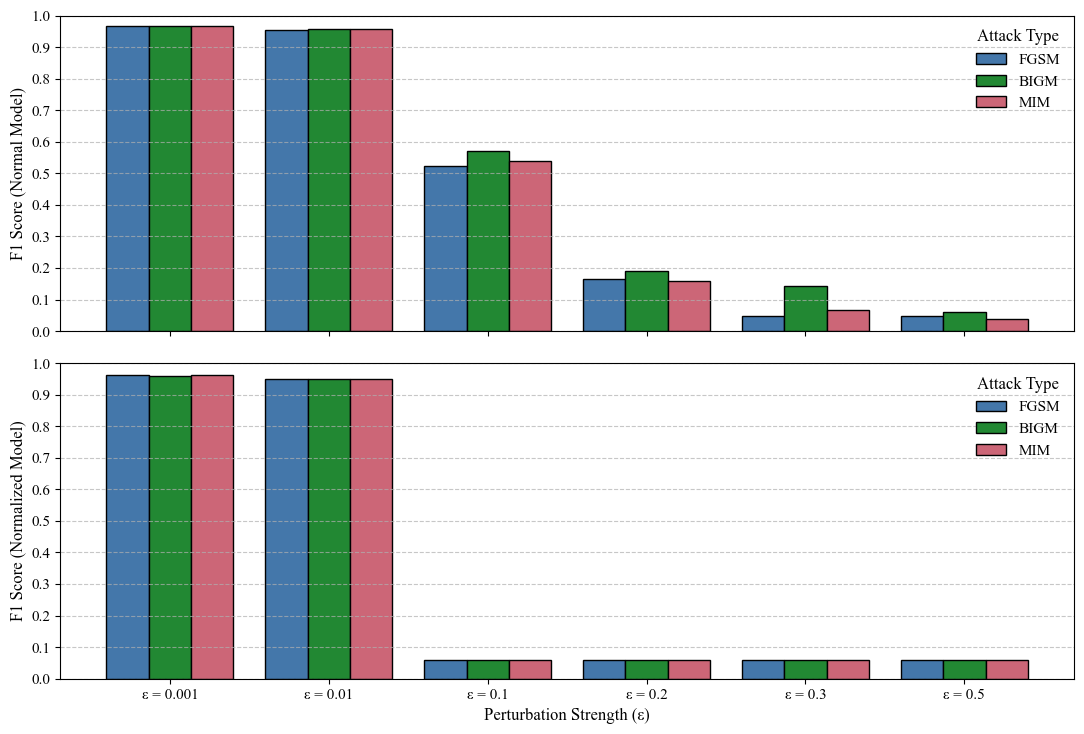

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


def plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as="f1_scores_grouped.pdf",
    caption="Caption",
):
    attack_order = ["FGSM", "BIGM", "MIM"]
    models = ["MobileNetV3"]

    # Unique colors for each (model, attack)
    color_map = {
        ("MobileNetV3", "FGSM"): "#4477AA",  # blue
        ("MobileNetV3", "BIGM"): "#228833",  # green
        ("MobileNetV3", "MIM"): "#CC6677",  # red
        # ("MobileNetV3", "FGSM"): "#66CCEE",  # teal
        # ("MobileNetV3", "BIGM"): "#AA4499",  # olive
        # ("MobileNetV3", "MIM"): "#DDCC77",  # gold
    }

    fname = Path(save_as).stem
    latex_code_normal = springerify_latex_table_long(
        make_score_table(normal_f1_scores),
        caption=caption.replace(" models ", " models (on normal data) "),
        label=f"tab:{fname}_normal",
    )
    latex_code_normalized = springerify_latex_table_long(
        make_score_table(normalized_f1_scores),
        caption=caption.replace(" models ", " models (on normalized data) "),
        label=f"tab:{fname}_normalized",
    )

    # combine the two latex codes
    latex_code = f"{latex_code_normal}\n\n{latex_code_normalized}"

    with open(out_dir / f"{fname}.tex", "w") as f:
        f.write(latex_code)

    # Extract all (attack, eps) keys
    all_keys = set()
    for model_scores in [normal_f1_scores, normalized_f1_scores]:
        for scores in model_scores.values():
            all_keys.update(scores.keys())

    parsed_keys = [
        (k.split("(")[0], float(k.split("(")[1].rstrip(")"))) for k in all_keys
    ]
    eps_values = sorted(set(eps for _, eps in parsed_keys))
    ordered_labels = [
        (atk, eps)
        for eps in eps_values
        for atk in attack_order
        if (atk, eps) in parsed_keys
    ]

    n_eps = len(eps_values)
    n_atks = len(attack_order)
    group_width = 0.8
    bar_width = group_width / n_atks
    eps_indices = np.arange(n_eps)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

    for ax, f1_dict, label in zip(
        axes, [normal_f1_scores, normalized_f1_scores], ["Normal", "Normalized"]
    ):
        for mid, model in enumerate(models):
            alpha = 1  # 0.99 if mid == 0 else 0.4  # Different alpha for each model
            for j, atk in enumerate(attack_order):
                heights = []
                for eps in eps_values:
                    key = f"{atk}({eps})"
                    heights.append(f1_dict.get(model, {}).get(key, 0.0))
                x_pos = eps_indices + j * bar_width - (group_width - bar_width) / 2
                ax.bar(
                    x_pos,
                    heights,
                    width=bar_width,
                    color=color_map[(model, atk)],
                    alpha=alpha,
                    edgecolor="black",
                    label=f"{atk}",
                )

        ax.set_ylabel(f"F1 Score ({label} Model)")
        # ax.set_title(f"{label} Adversarial Classification Performance")
        ax.set_ylim(0, 1.0)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.set_xticks(eps_indices)
        ax.set_xticklabels([f"ε = {eps}" for eps in eps_values])

        # Construct grouped legend
        handles = []
        for model in models:
            handles.append(mpatches.Patch(color="white", label=f"{model}:"))
            for atk in attack_order:
                handles.append(
                    mpatches.Patch(
                        color=color_map[(model, atk)],
                        label=f"  {atk}",
                        edgecolor="black",
                    )
                )
        ax.legend(
            # handles=handles,
            title="Attack Type",
            loc="upper right",
            # ncol=2,
            frameon=False,
        )

    axes[-1].set_xlabel("Perturbation Strength (ε)")
    plt.tight_layout()
    plt.savefig(out_dir / save_as, dpi=300)
    plt.show()


# F1-Scores of adversarially trained models after defending the MobileNet-based adversarial attacks with RDU-Net
plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_clf.pdf",
    caption=f"F1 Scores of baseline models after {atk_gen}-based adversarial attacks",
)

#### Attack on Adversarially Trained Model

Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
LaTeX table generated successfully.
LaTeX table generated successfully.


C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


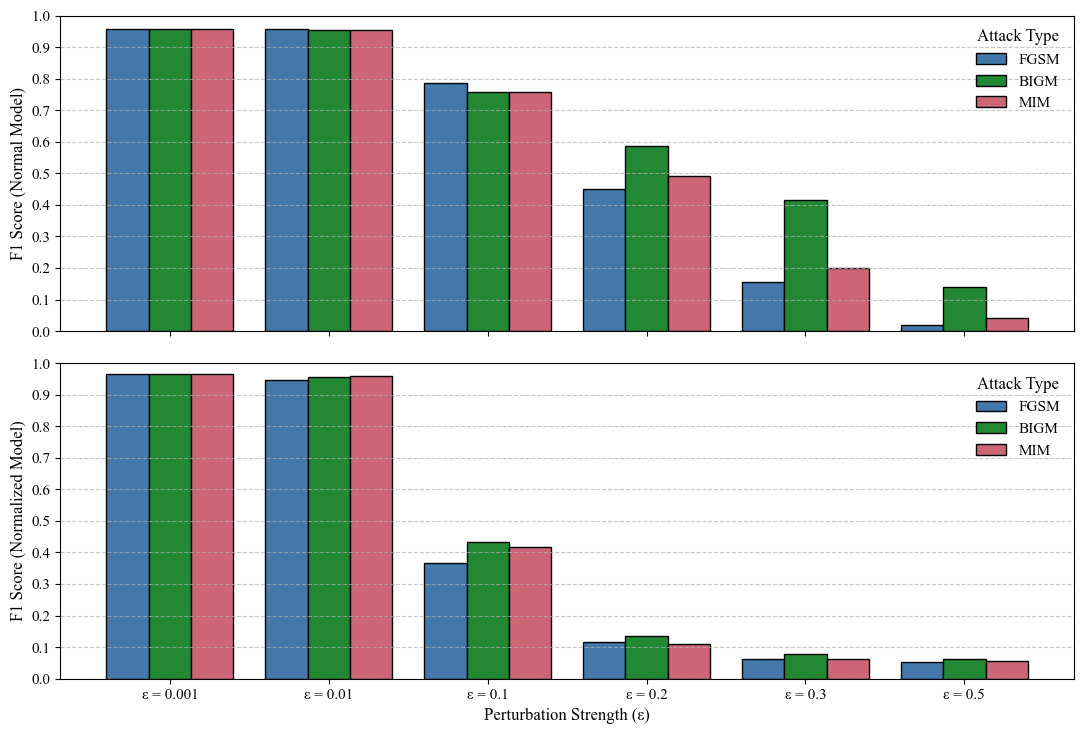

In [21]:
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        adv_atc_f1 = (
            df.query("clf_model==@clf_model")
            .groupby("adversarial_name")
            .adv_atc_f1.mean()
            .to_dict()
        )
        for atk_eps, f1_score in adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue

    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        adv_atc_f1 = (
            df.query("clf_model==@clf_model")
            .groupby("adversarial_name")
            .adv_atc_f1.mean()
            .to_dict()
        )
        for atk_eps, f1_score in adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_atc.pdf",
    caption=f"F1 Scores of adversarially trained models after {atk_gen}-based adversarial attacks",
)

#### Attack Defense with U-Net: CLF

C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2279475783.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2279475783.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2279475783.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2279475783.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\User

Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
LaTeX table generated successfully.
LaTeX table generated successfully.


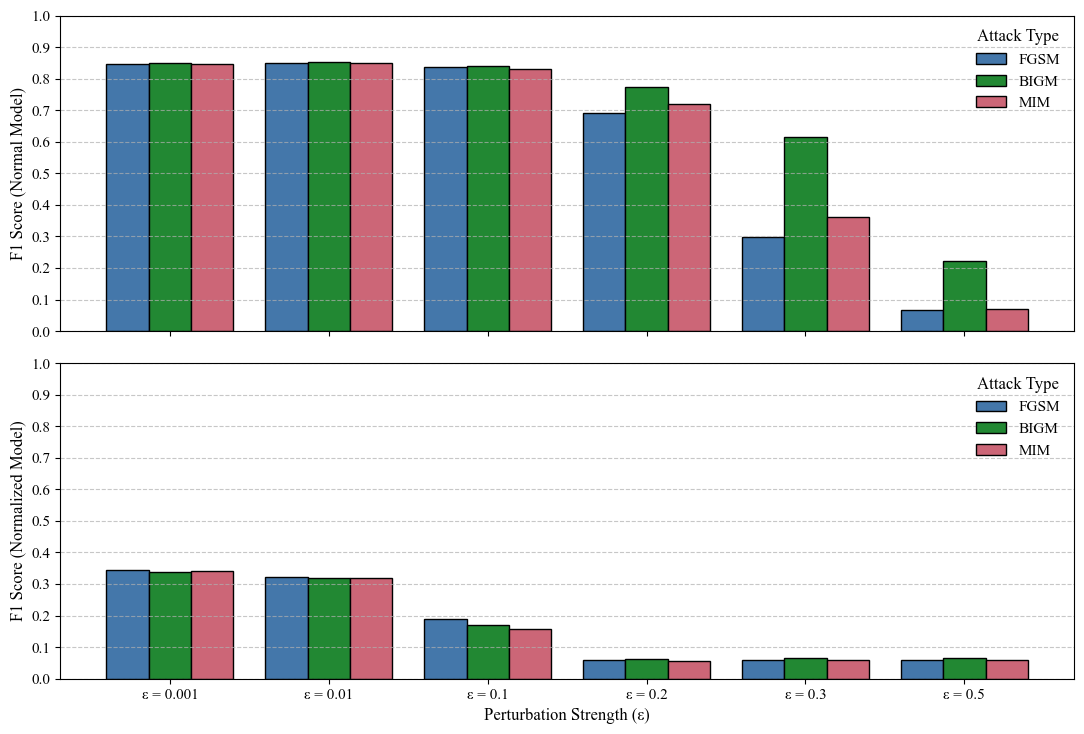

In [22]:
# plot a groupped bar plot


recon_model = "unet_custom"  # or "unet"
# recon_adv_clf_f1, recon_adv_atc_f1
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_clf_f1 = (
            ndf.groupby("adversarial_name").recon_adv_clf_f1.mean().to_dict()
        )

        for atk_eps, f1_score in recon_adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_clf_f1 = (
            ndf.groupby("adversarial_name").recon_adv_clf_f1.mean().to_dict()
        )
        for atk_eps, f1_score in recon_adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_unet_clf.pdf",
    caption=f"F1 Scores of baseline models after defending {atk_gen}-based adversarial attacks by U-Net",
)

#### Attack Defense with RDUNet: CLF

C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\895507164.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\895507164.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\895507164.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\895507164.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\Users\Vi

Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
LaTeX table generated successfully.
LaTeX table generated successfully.


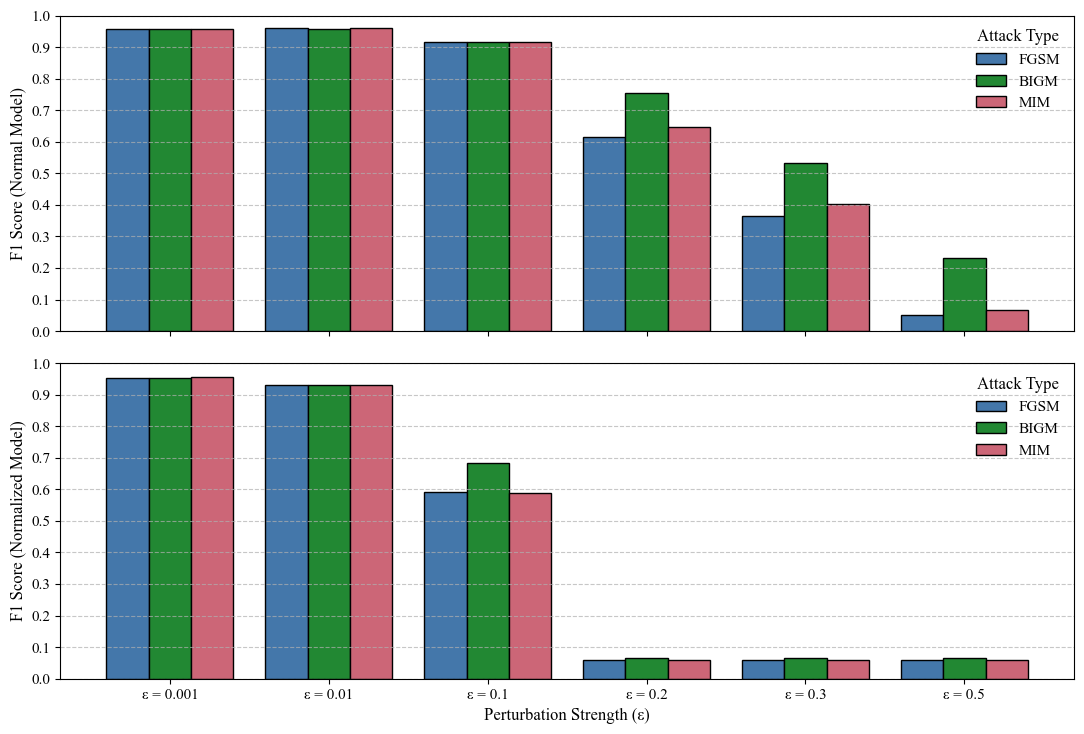

In [23]:
# plot a groupped bar plot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


recon_model = "rdunet"  # or "unet"
# recon_adv_clf_f1, recon_adv_atc_f1
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_clf_f1 = (
            ndf.groupby("adversarial_name").recon_adv_clf_f1.mean().to_dict()
        )

        for atk_eps, f1_score in recon_adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_clf_f1 = (
            ndf.groupby("adversarial_name").recon_adv_clf_f1.mean().to_dict()
        )
        for atk_eps, f1_score in recon_adv_clf_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_rdunet_clf.pdf",
    caption=f"F1 Scores of baseline models after defending {atk_gen}-based adversarial attacks by RDU-Net",
)

#### Attack Defense with UNet: ATC

C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\3790842380.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\3790842380.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\3790842380.py:48: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\3790842380.py:48: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\User

Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
LaTeX table generated successfully.
LaTeX table generated successfully.


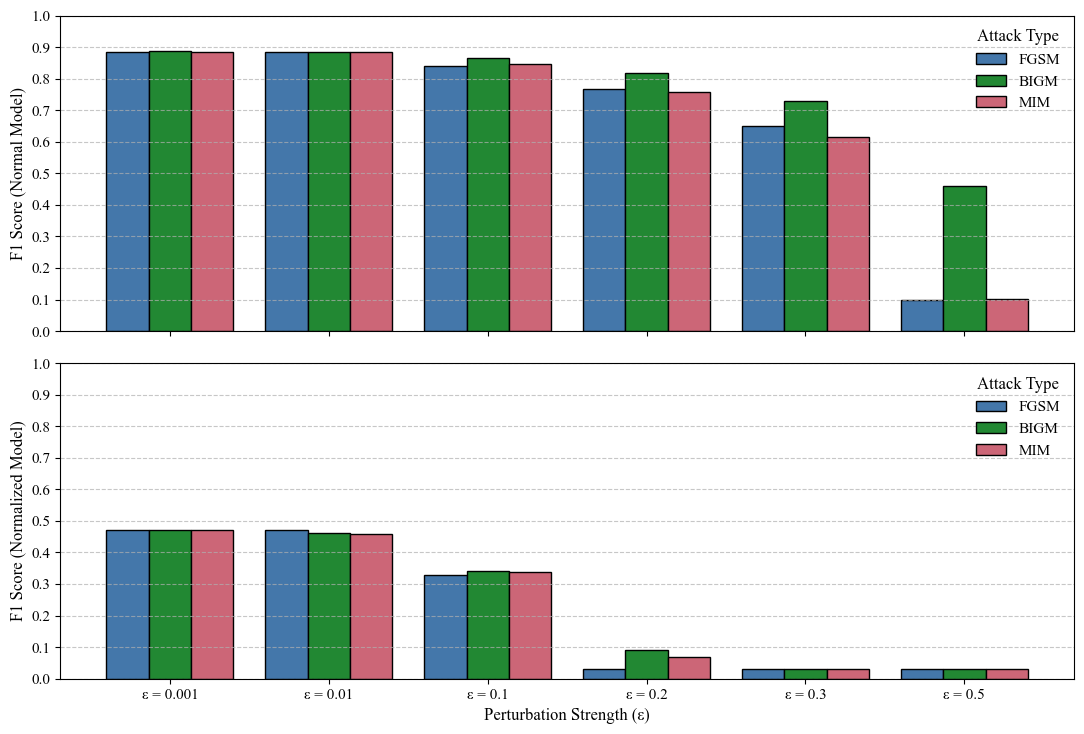

In [24]:
recon_model = "unet_custom"  # or "unet"
# recon_adv_clf_f1, recon_adv_atc_f1
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_atc_f1 = (
            ndf.groupby("adversarial_name").recon_adv_atc_f1.mean().to_dict()
        )

        for atk_eps, f1_score in recon_adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_atc_f1 = (
            ndf.groupby("adversarial_name").recon_adv_atc_f1.mean().to_dict()
        )
        for atk_eps, f1_score in recon_adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_unet_atc.pdf",
    caption=f"F1 Scores of adversarially trained models after defending {atk_gen}-based adversarial attacks by U-Net",
)

#### Attack Defense with RDUNet: ATC

C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\1067721805.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\1067721805.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\1067721805.py:48: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\1067721805.py:48: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\607343160.py:103: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\User

Skipping saliencymapmethod_eps_0.0 for MobileNetV3
Skipping saliencymapmethod_eps_0.0 for ResNet18
LaTeX table generated successfully.
LaTeX table generated successfully.


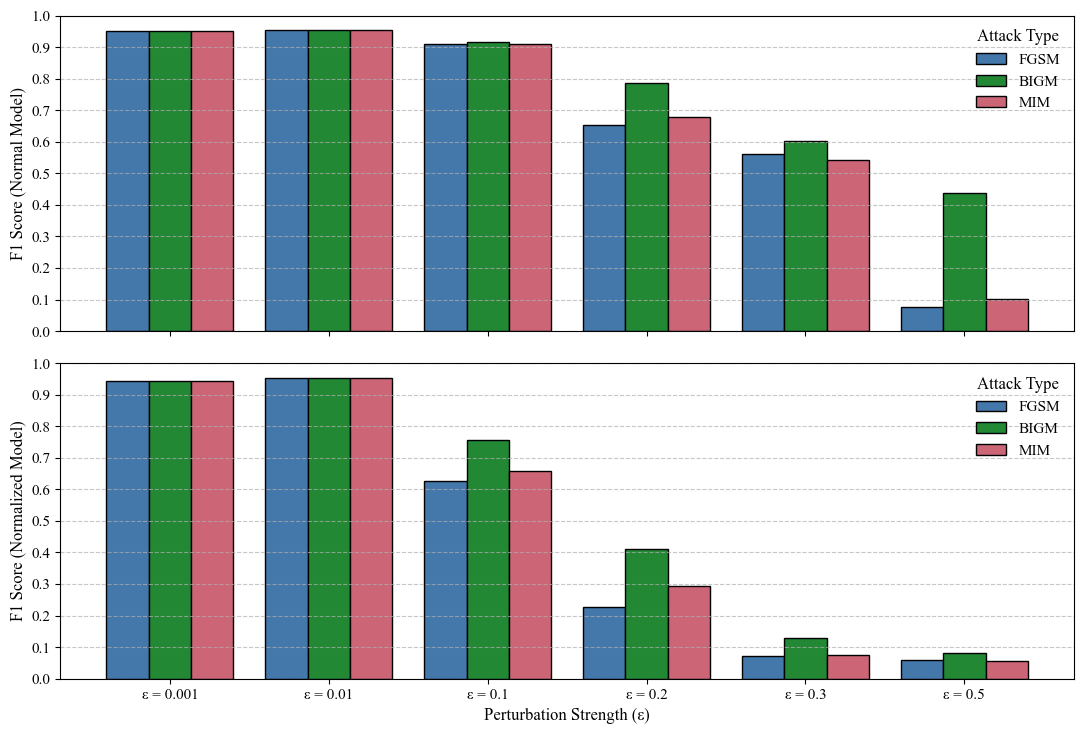

In [25]:
recon_model = "rdunet"  # or "unet"
# recon_adv_clf_f1, recon_adv_atc_f1
# contains: model {atk_eps:f1_score }
normal_f1_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_atc_f1 = (
            ndf.groupby("adversarial_name").recon_adv_atc_f1.mean().to_dict()
        )

        for atk_eps, f1_score in recon_adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normal_f1_scores.setdefault(clf_model, {})
            normal_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

normalized_f1_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.clf_model.unique())
    for clf_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("clf_model==@clf_model")
        # now filter by recon_model
        ndf = ndf[df.ae_model.apply(lambda x: recon_model in x)]
        recon_adv_atc_f1 = (
            ndf.groupby("adversarial_name").recon_adv_atc_f1.mean().to_dict()
        )
        for atk_eps, f1_score in recon_adv_atc_f1.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {clf_model}")
                continue
            clf_model = "ResNet18" if "resnet" in clf_model.lower() else "MobileNetV3"
            if clf_model != main_model:
                continue
            normalized_f1_scores.setdefault(clf_model, {})
            normalized_f1_scores[clf_model][f"{atk_name}({eps})"] = f1_score

plot_grouped_atk_f1(
    normal_f1_scores,
    normalized_f1_scores,
    save_as=f"f1_scores_{attack_model}_adv_rdunet_atc.pdf",
    caption=f"F1 Scores of adversarially trained models after defending {atk_gen}-based adversarial attacks by RDU-Net",
)

### MAE Visualization

Skipping saliencymapmethod_eps_0.0 for RDU-Net
Skipping saliencymapmethod_eps_0.0 for U-Net
LaTeX table generated successfully.
LaTeX table generated successfully.


C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\4133740123.py:137: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\4133740123.py:137: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


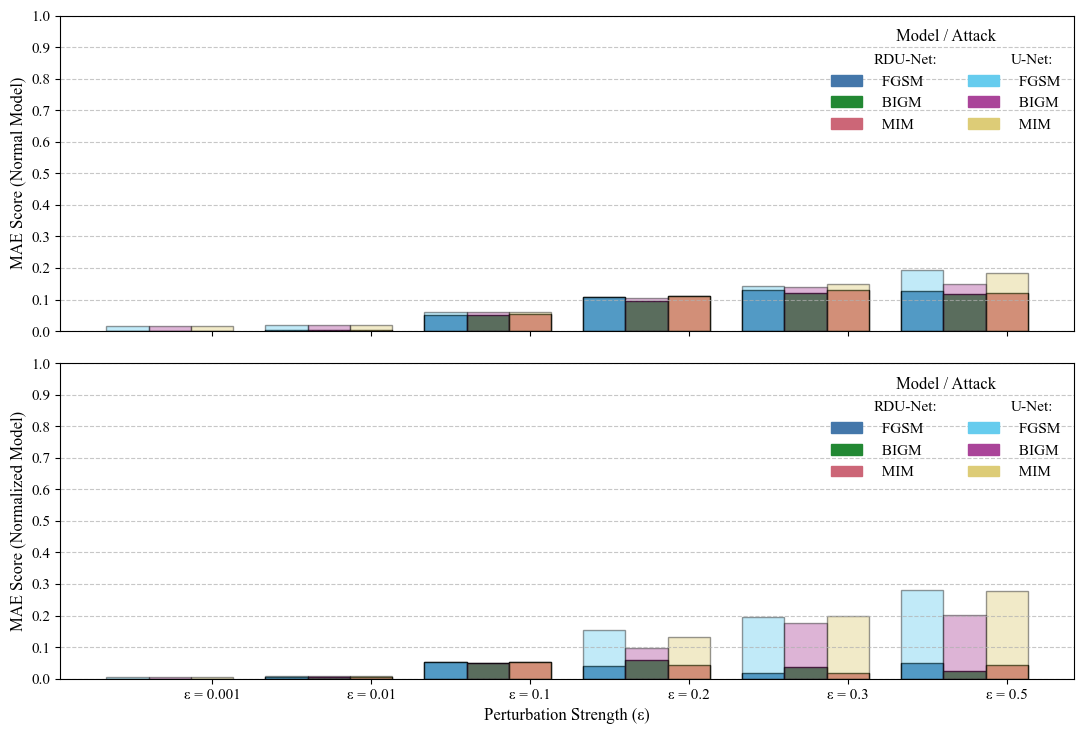

In [35]:
normalized_mae_scores = {}
for csv_file in normalized_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.ae_model.unique())
    for ae_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("ae_model==@ae_model")
        adv_mae = ndf.groupby("adversarial_name").adv_recon_mae.mean().to_dict()
        for atk_eps, mae_score in adv_mae.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {ae_model}")
                continue
            ae_model = "RDU-Net" if "rdu" in ae_model.lower() else "U-Net"
            normalized_mae_scores.setdefault(ae_model, {})
            normalized_mae_scores[ae_model][f"{atk_name}({eps})"] = mae_score

normal_mae_scores = {}
for csv_file in normal_csv_files:
    if attack_model not in str(csv_file).lower():
        continue
    df = pd.read_csv(csv_file)
    df["eps"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[1])
    df["atk_name"] = df.adversarial_name.apply(lambda x: refine_adv_name(x)[0])
    # sort by eps
    df = df.sort_values(by="eps")
    models = sorted(df.ae_model.unique())
    for ae_model in models:
        # not using query here because we want to filter by ae_model
        ndf = df.query("ae_model==@ae_model")
        adv_mae = ndf.groupby("adversarial_name").adv_recon_mae.mean().to_dict()
        for atk_eps, mae_score in adv_mae.items():
            atk_name, eps = refine_adv_name(atk_eps)
            if eps == 0 or atk_name == "":
                print(f"Skipping {atk_eps} for {ae_model}")
                continue
            ae_model = "RDU-Net" if "rdu" in ae_model.lower() else "U-Net"
            normal_mae_scores.setdefault(ae_model, {})
            normal_mae_scores[ae_model][f"{atk_name}({eps})"] = mae_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_grouped_atk_mae(
    normal_mae_scores,
    normalized_mae_scores,
    save_as="mae_scores_grouped.pdf",
    caption="Caption",
):
    attack_order = ["FGSM", "BIGM", "MIM"]
    models = ["RDU-Net", "U-Net"]
    # Unique colors for each (model, attack)
    color_map = {
        ("RDU-Net", "FGSM"): "#4477AA",  # blue
        ("RDU-Net", "BIGM"): "#228833",  # green
        ("RDU-Net", "MIM"): "#CC6677",  # red
        ("U-Net", "FGSM"): "#66CCEE",  # teal
        ("U-Net", "BIGM"): "#AA4499",  # olive
        ("U-Net", "MIM"): "#DDCC77",  # gold
    }
    fname = Path(save_as).stem
    latex_code_normal = springerify_latex_table_long(
        make_score_table(normal_mae_scores, is_mae=True),
        caption=caption + " (on normal data)",
        label=f"tab:{fname}_normal",
    )
    latex_code_normalized = springerify_latex_table_long(
        make_score_table(normalized_mae_scores, is_mae=True),
        caption=caption + "(on normalized data)",
        label=f"tab:{fname}_normalized",
    )
    # combine the two latex codes
    latex_code = f"{latex_code_normal}\n\n{latex_code_normalized}"
    with open(f"{fname}.tex", "w") as f:
        f.write(latex_code)
    # Extract all (attack, eps) keys
    all_keys = set()
    for model_scores in [normal_mae_scores, normalized_mae_scores]:
        for scores in model_scores.values():
            all_keys.update(scores.keys())
    parsed_keys = [
        (k.split("(")[0], float(k.split("(")[1].rstrip(")"))) for k in all_keys
    ]
    eps_values = sorted(set(eps for _, eps in parsed_keys))
    ordered_labels = [
        (atk, eps)
        for eps in eps_values
        for atk in attack_order
        if (atk, eps) in parsed_keys
    ]
    n_eps = len(eps_values)
    n_atks = len(attack_order)
    group_width = 0.8
    bar_width = group_width / n_atks
    eps_indices = np.arange(n_eps)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
    for ax, mae_dict, label in zip(
        axes, [normal_mae_scores, normalized_mae_scores], ["Normal", "Normalized"]
    ):
        for mid, model in enumerate(models):
            alpha = 0.99 if mid == 0 else 0.4
            for j, atk in enumerate(attack_order):
                heights = []
                for eps in eps_values:
                    key = f"{atk}({eps})"
                    heights.append(mae_dict.get(model, {}).get(key, 0.0))
                x_pos = eps_indices + j * bar_width - (group_width - bar_width)
                ax.bar(
                    x_pos,
                    heights,
                    width=bar_width,
                    color=color_map[(model, atk)],
                    alpha=alpha,
                    edgecolor="black",
                    label=f"{model}-{atk}",
                )
        ax.set_ylabel(f"MAE Score ({label} Model)")
        ax.set_ylim(0, 1.0)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.set_xticks(eps_indices)
        ax.set_xticklabels([f"ε = {eps}" for eps in eps_values])
        # Construct grouped legend
        handles = []
        for model in models:
            handles.append(mpatches.Patch(color="white", label=f"{model}:"))
            for atk in attack_order:
                handles.append(
                    mpatches.Patch(
                        color=color_map[(model, atk)],
                        label=f"  {atk}",
                        edgecolor="black",
                    )
                )
        ax.legend(
            handles=handles,
            title="Model / Attack",
            loc="upper right",
            ncol=2,
            frameon=False,
        )
    axes[-1].set_xlabel("Perturbation Strength (ε)")
    plt.tight_layout()
    plt.savefig(save_as, dpi=300)
    plt.show()


plot_grouped_atk_mae(
    normal_mae_scores,
    normalized_mae_scores,
    save_as=out_dir / f"mae_scores_{attack_model}_adv_recon.pdf",
    caption=f"MAE Scores for {atk_gen}-based adversarial attacks",
)

### Find Differences

In [33]:
import re
import pandas as pd


def parse_latex_tabular(tabular_text):
    """Extracts headers and data from a tabular environment and returns a DataFrame."""
    # Remove LaTeX commands/lines we don't want
    lines = [
        line
        for line in tabular_text.splitlines()
        if line.strip()
        and not line.strip().startswith("%")
        and "\\hline" not in line
        and "noalign" not in line
        and "tabular" not in line
    ]
    # Remove possible \end{tabular} and \begin{tabular}{...}
    lines = [
        line
        for line in lines
        if not line.strip().startswith("\\end")
        and not line.strip().startswith("\\begin")
    ]
    # Remove table captions/labels if present
    lines = [
        line
        for line in lines
        if not line.strip().startswith("\\caption")
        and not line.strip().startswith("\\label")
    ]
    # Split rows
    records = [
        re.split(r"\s*&\s*", line.strip().rstrip("\\\\"))
        for line in lines
        if "&" in line
    ]
    if not records:
        return None
    header = records[0]
    data = records[1:]
    df = pd.DataFrame(data, columns=header)
    # Try to convert numeric columns
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass
    return df


def extract_tabular_blocks(texfile):
    """Extracts all tabular blocks from a .tex file as text."""
    with open(texfile, encoding="utf8") as f:
        tex = f.read()
    tabulars = re.findall(
        r"\\begin{tabular}{[^}]+}(.*?)\\end{tabular}", tex, flags=re.DOTALL
    )
    return tabulars


def dataframe_numeric_diff(df1, df2):
    df1_aligned, df2_aligned = df1.align(df2, join="outer", axis=1)
    df1_aligned["eps_str"] = df1_aligned["$\epsilon$"].astype(str)
    df2_aligned["eps_str"] = df2_aligned["$\epsilon$"].astype(str)

    numeric_cols = [
        col
        for col in df1_aligned.columns
        if pd.api.types.is_numeric_dtype(df1_aligned[col])
    ]
    diff_values = df1_aligned[numeric_cols].astype(float) - df2_aligned[
        numeric_cols
    ].astype(float)

    # Positive/negative difference stats
    positive_values = diff_values[diff_values > 0]
    negative_values = diff_values[diff_values < 0]

    num_positive = positive_values.count().sum()
    num_negative = negative_values.count().sum()

    avg_positive = positive_values.mean().mean()
    avg_negative = negative_values.mean().mean()

    # Add back non-numeric columns
    result = diff_values.copy()
    for col in df1_aligned.columns:
        if col not in numeric_cols:
            result[col] = df1_aligned[col]

    result = result[df1.columns]  # preserve column order
    max_val = result[numeric_cols].max().max()
    min_val = result[numeric_cols].min().min()

    max_idx = result[numeric_cols].stack().idxmax()
    min_idx = result[numeric_cols].stack().idxmin()

    max_row = result.loc[max_idx[0]].copy()
    max_row["metric"] = max_idx[1]
    max_row["diff_value"] = max_val

    min_row = result.loc[min_idx[0]].copy()
    min_row["metric"] = min_idx[1]
    min_row["diff_value"] = min_val

    # Format
    max_row_fmt = f"{max_row['Classifier']}({max_row['metric']}({max_row['eps_str']}))"
    min_row_fmt = f"{min_row['Classifier']}({min_row['metric']}({min_row['eps_str']}))"

    # Get corresponding values from df1 and df2
    max_val_df1 = df1_aligned.loc[max_idx[0], max_idx[1]]
    max_val_df2 = df2_aligned.loc[max_idx[0], max_idx[1]]

    min_val_df1 = df1_aligned.loc[min_idx[0], min_idx[1]]
    min_val_df2 = df2_aligned.loc[min_idx[0], min_idx[1]]

    max_val_tuple = (max_val_df1, max_val_df2)
    min_val_tuple = (min_val_df1, min_val_df2)
    avg_diff = diff_values.mean().mean()

    return (
        result,
        max_val,
        min_val,
        max_row_fmt,
        min_row_fmt,
        num_positive,
        num_negative,
        avg_positive,
        avg_negative,
        max_val_tuple,
        min_val_tuple,
        avg_diff,
    )


baseline_tex = "f1_scores_mobilenet_adv_clf.tex"

comparing_tex = [
    "f1_scores_mobilenet_adv_atc.tex",
    "f1_scores_mobilenet_adv_unet_clf.tex",
    "f1_scores_mobilenet_adv_rdunet_clf.tex",
    "f1_scores_mobilenet_adv_unet_atc.tex",
    "f1_scores_mobilenet_adv_rdunet_atc.tex",
]
comparing_tex2 = [
    "f1_scores_resnet18_adv_atc.tex",
    "f1_scores_resnet18_adv_unet_clf.tex",
    "f1_scores_resnet18_adv_rdunet_clf.tex",
    "f1_scores_resnet18_adv_unet_atc.tex",
    "f1_scores_resnet18_adv_rdunet_atc.tex",
]

tabular_blocks = extract_tabular_blocks(baseline_tex)
baseline_dfs = [parse_latex_tabular(tb) for tb in tabular_blocks]


def get_diff_df(baseline_dfs, comparing_tex):
    diffs = {}
    for tex in comparing_tex:
        tabular_blocks = extract_tabular_blocks(tex)
        comparing_dfs = [parse_latex_tabular(tb) for tb in tabular_blocks]
        diffs.setdefault(tex, {})
        for comp_df, base_df, dtype in zip(
            comparing_dfs, baseline_dfs, ["normal", "normalized"]
        ):
            # only use mobilenet
            comp_df = comp_df[comp_df["Classifier"].apply(lambda x: "mob" in x.lower())]
            base_df = base_df[base_df["Classifier"].apply(lambda x: "mob" in x.lower())]

            base_df["eps_str"] = base_df["$\epsilon$"].astype(str)
            comp_df["eps_str"] = comp_df["$\epsilon$"].astype(str)
            (
                diff,
                max_val,
                min_val,
                max_row,
                min_row,
                num_positive,
                num_negative,
                avg_positive,
                avg_negative,
                max_val_tuple,
                min_val_tuple,
                avg_diff,
            ) = dataframe_numeric_diff(comp_df, base_df)
            # max_row = " ".join([v[:4] for v in max_row.astype(str).tolist()])
            # min_row = " ".join([v[:4] for v in min_row.astype(str).tolist()])
            diffs[tex][dtype] = {
                "max_diff": max_val,
                "min_diff": min_val,
                "max_row": max_row,
                "min_row": min_row,
                "num_positive": num_positive,
                "num_negative": num_negative,
                "avg_positive": avg_positive,
                "avg_negative": avg_negative,
                "max_val_tuple": max_val_tuple,
                "min_val_tuple": min_val_tuple,
                "avg_diff": avg_diff,
            }
    flat = []
    for texfile, sub in diffs.items():
        for phase, stats in sub.items():
            flat.append(
                {
                    "tex_file": texfile,
                    "data_type": phase,
                    "max_diff": stats["max_diff"],
                    "min_diff": stats["min_diff"],
                    "max_row": stats["max_row"],
                    "min_row": stats["min_row"],
                    "num_positive": stats["num_positive"],
                    "num_negative": stats["num_negative"],
                    "avg_positive": stats["avg_positive"],
                    "avg_negative": stats["avg_negative"],
                    "max_val_tuple": stats["max_val_tuple"],
                    "min_val_tuple": stats["min_val_tuple"],
                    "avg_diff": stats["avg_diff"],
                }
            )
    return pd.DataFrame(flat)


def get_eval_type(tex_file):
    adv_generator = "ResNet" if "resnet" in tex_file else "MobNet"
    fname = Path(tex_file).stem
    classifier = "ATC" if fname.endswith("atc") else "CLF"
    ae_model = "RDUNet" if "rdunet" in fname else "UNet" if "unet" in fname else ""
    if ae_model != "":
        full_name = f"{classifier}({ae_model}({adv_generator}))"
    else:
        full_name = f"{classifier}({adv_generator})"
    return full_name


diffs = get_diff_df(baseline_dfs, comparing_tex)
diffs2 = get_diff_df(baseline_dfs, comparing_tex2)
# merge them
diffs = pd.concat([diffs, diffs2], ignore_index=True)
diffs["eval_type"] = diffs["tex_file"].apply(get_eval_type)
diffs["clf_model"] = diffs.eval_type.apply(lambda x: "CLF" if "CLF" in x else "ATC")
diffs["ae_model"] = diffs.eval_type.apply(
    lambda x: "RDUNet" if "RDUNet" in x else "UNet" if "UNet" in x else "No Defense"
)
# put evaltype in the second column
first_cols = ["tex_file", "eval_type", "max_val_tuple", "min_val_tuple", "ae_model"]
diffs = diffs[first_cols + [col for col in diffs.columns if col not in first_cols]]
diffs["generator"] = diffs.eval_type.apply(
    lambda x: "ResNet" if "ResNet" in x else "MobileNet"
)


diffs.sort_values("clf_model")

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:171: SyntaxWarning: invalid escape sequence '\e'
<>:172: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:171: SyntaxWarning: invalid escape sequence '\e'
<>:172: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2578682166.py:63: SyntaxWarning: invalid escape sequence '\e'
  df1_aligned["eps_str"] = df1_aligned["$\epsilon$"].astype(str)
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2578682166.py:64: SyntaxWarning: invalid escape sequence '\e'
  df2_aligned["eps_str"] = df2_aligned["$\epsilon$"].astype(str)
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2578682166.py:171: SyntaxWarning: invalid escape sequence '\e'
  base_df["eps_str"] = base_df["$\epsilon$"].astype(str)
C:\Users\Viper\AppData\Local\Temp\ipykernel_16736\2578682166.py:

,tex_file,eval_type,max_val_tuple,min_val_tuple,ae_model,data_type,max_diff,min_diff,max_row,min_row,num_positive,num_negative,avg_positive,avg_negative,avg_diff,clf_model,generator
0,f1_scores_mobilenet_adv_atc.tex,ATC(MobNet),"(0.585, 0.19)","(0.019, 0.047)",No Defense,normal,0.395,-0.028,MobNet(BIGM(0.2)),MobNet(FGSM(0.5)),12,6,0.190833,-0.010333,0.092833,ATC,MobileNet
17,f1_scores_resnet18_adv_unet_atc.tex,ATC(UNet(ResNet)),"(0.295, 0.06)","(0.444, 0.95)",UNet,normalized,0.235,-0.506,MobNet(FGSM(0.1)),MobNet(MIM (0.01)),3,15,0.223000,-0.215667,-0.106917,ATC,ResNet
16,f1_scores_resnet18_adv_unet_atc.tex,ATC(UNet(ResNet)),"(0.609, 0.166)","(0.884, 0.967)",UNet,normal,0.443,-0.083,MobNet(FGSM(0.2)),MobNet(BIGM(0.001)),11,7,0.289472,-0.072000,0.110583,ATC,ResNet
11,f1_scores_resnet18_adv_atc.tex,ATC(ResNet),"(0.498, 0.06)","(0.916, 0.948)",No Defense,normalized,0.438,-0.032,MobNet(FGSM(0.1)),MobNet(FGSM(0.01)),13,5,0.110850,-0.012833,0.056250,ATC,ResNet
10,f1_scores_resnet18_adv_atc.tex,ATC(ResNet),"(0.512, 0.19)","(0.021, 0.047)",No Defense,normal,0.322,-0.026,MobNet(BIGM(0.2)),MobNet(FGSM(0.5)),12,6,0.168494,-0.009944,0.077542,ATC,ResNet
18,f1_scores_resnet18_adv_rdunet_atc.tex,ATC(RDUNet(ResNet)),"(0.651, 0.19)","(0.95, 0.967)",RDUNet,normal,0.461,-0.017,MobNet(BIGM(0.2)),MobNet(BIGM(0.001)),12,6,0.291333,-0.011167,0.142875,ATC,ResNet
8,f1_scores_mobilenet_adv_rdunet_atc.tex,ATC(RDUNet(MobNet)),"(0.788, 0.19)","(0.951, 0.966)",RDUNet,normal,0.598,-0.015,MobNet(BIGM(0.2)),MobNet(FGSM(0.001)),12,5,0.385667,-0.011333,0.190625,ATC,MobileNet
9,f1_scores_mobilenet_adv_rdunet_atc.tex,ATC(RDUNet(MobNet)),"(0.757, 0.06)","(0.943, 0.962)",RDUNet,normalized,0.697,-0.019,MobNet(BIGM(0.1)),MobNet(MIM (0.001)),14,4,0.197067,-0.015667,0.111917,ATC,MobileNet
6,f1_scores_mobilenet_adv_unet_atc.tex,ATC(UNet(MobNet)),"(0.817, 0.19)","(0.884, 0.966)",UNet,normal,0.627,-0.082,MobNet(BIGM(0.2)),MobNet(FGSM(0.001)),12,6,0.416500,-0.076500,0.189125,ATC,MobileNet
1,f1_scores_mobilenet_adv_atc.tex,ATC(MobNet),"(0.433, 0.06)","(0.053, 0.06)",No Defense,normalized,0.373,-0.007,MobNet(BIGM(0.1)),MobNet(FGSM(0.5)),15,2,0.086056,-0.006000,0.052792,ATC,MobileNet


normal 0.12793333333333334


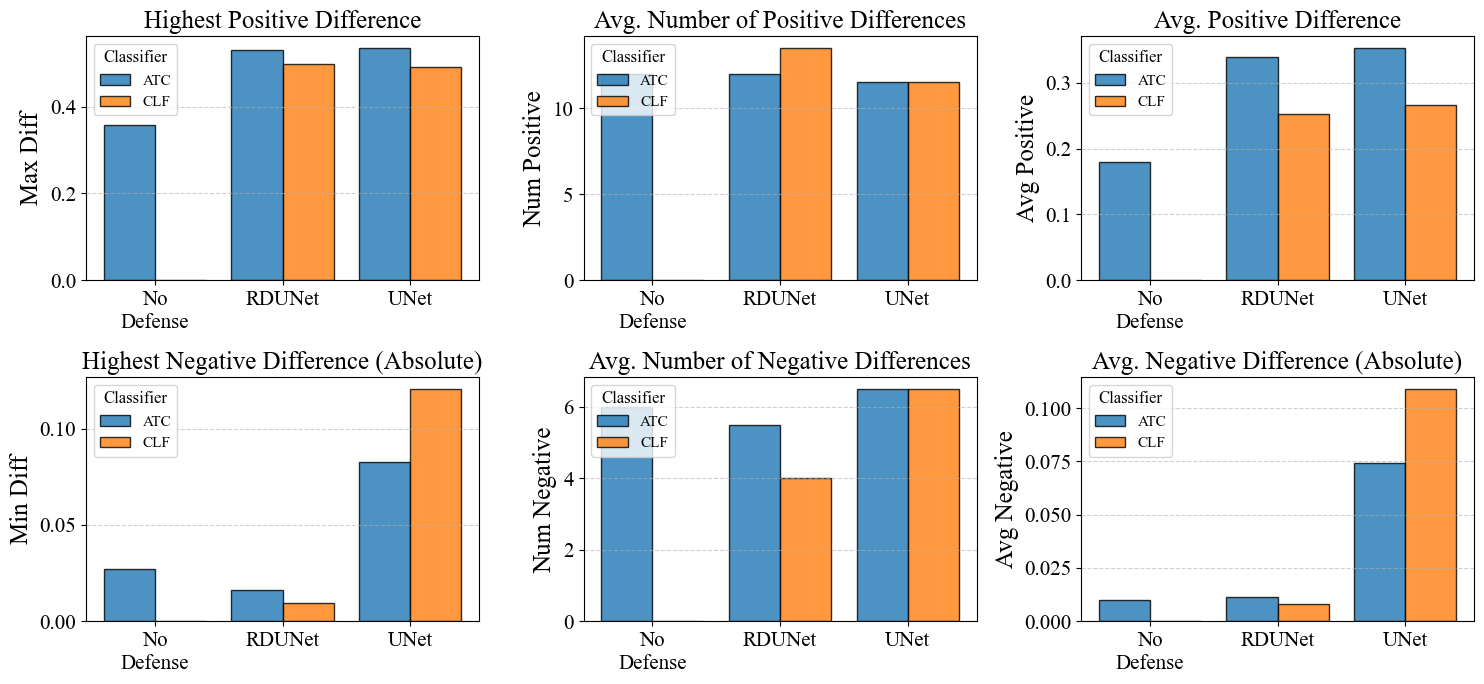

normalized -0.004666666666666661


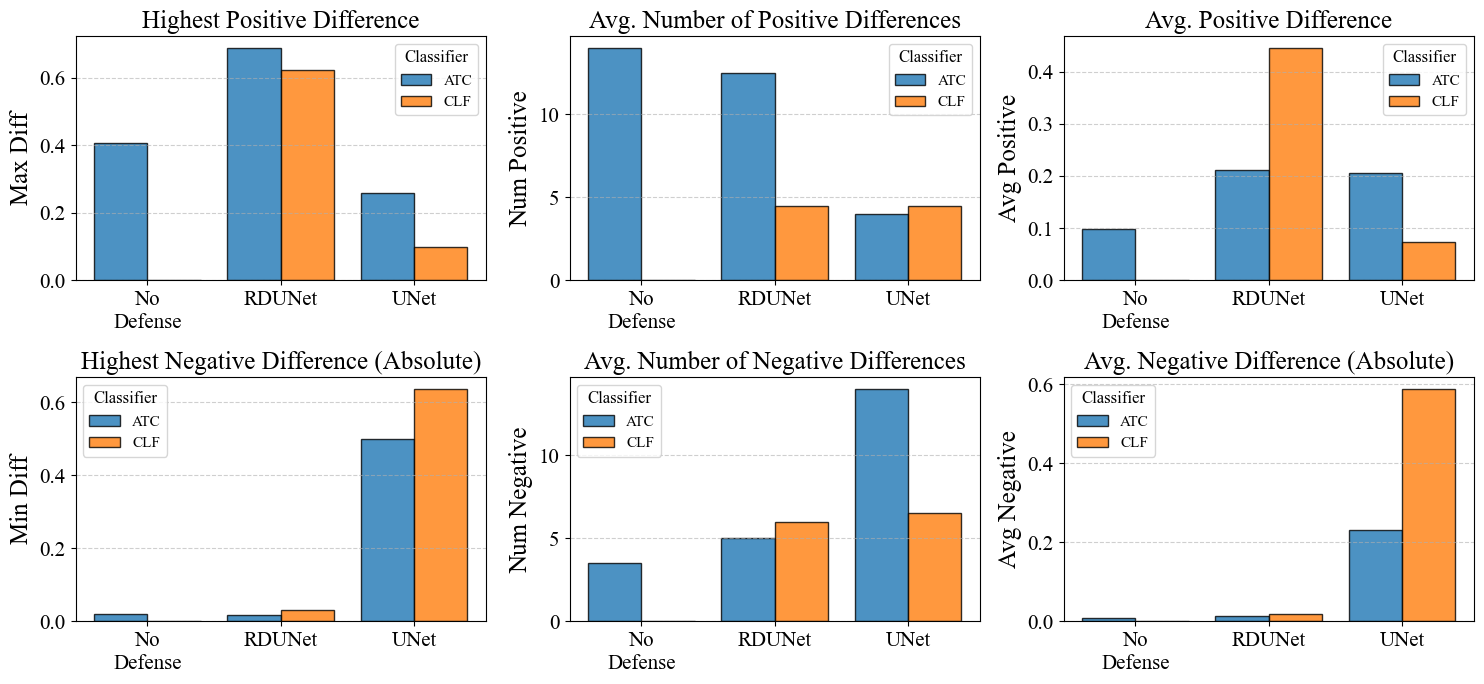

In [34]:
import matplotlib.pyplot as plt

for dtype in diffs.data_type.unique():

    res_df = (
        diffs.query("data_type==@dtype")
        .groupby(["ae_model", "clf_model"])[
            [
                "max_diff",
                "min_diff",
                "num_positive",
                "num_negative",
                "avg_positive",
                "avg_negative",
                "avg_diff",
            ]
        ]
        .mean()
        .reset_index()
    )
    print(dtype, diffs.query("data_type==@dtype").avg_diff.mean())
    metrics = [
        "max_diff",
        "num_positive",
        "avg_positive",
        "min_diff",
        "num_negative",
        "avg_negative",
    ]

    titles = [
        "Highest Positive Difference",
        "Avg. Number of Positive Differences",
        "Avg. Positive Difference",
        "Highest Negative Difference (Absolute)",
        "Avg. Number of Negative Differences",
        "Avg. Negative Difference (Absolute)",
    ]

    clf_models = res_df["clf_model"].unique()
    ae_models = res_df["ae_model"].unique()
    n_clfs = len(clf_models)
    x = np.arange(len(ae_models))  # Base positions for AE models
    width = 0.8 / n_clfs  # Width of each bar

    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
    axes = axes.flatten()

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i]

        for j, clf in enumerate(clf_models):
            subset = res_df[res_df["clf_model"] == clf]
            # Get y-values in correct order of AE models
            y = [
                (
                    subset[subset["ae_model"] == ae][metric].values[0]
                    if not subset[subset["ae_model"] == ae].empty
                    else 0
                )
                for ae in ae_models
            ]

            ax.bar(
                x + j * width,
                np.abs(y),
                width=width,
                label=clf,
                alpha=0.8,
                edgecolor="black",
            )
        # ae_models = [m.replace(" ", "\n") for m in ae_models]
        ax.set_title(title, fontsize=18)
        ax.set_ylabel(metric.replace("_", " ").title(), fontsize=18)
        ax.set_xticks(x + width * (n_clfs - 1) / 2)
        ax.set_xticklabels([m.replace(" ", "\n") for m in ae_models])
        # # update tick label size
        ax.tick_params(axis="x", labelsize=15)
        ax.tick_params(axis="y", labelsize=15)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.legend(title="Classifier")

    plt.tight_layout()
    plt.savefig(out_dir / f"final_metrics_{dtype}.pdf", dpi=300)
    plt.show()

In [271]:
res_df

,ae_model,clf_model,max_diff,min_diff,num_positive,num_negative,avg_positive,avg_negative
0,No Defense,ATC,0.45375,-0.08225,25.25,10.50,0.124857,-0.021365
1,RDUNet,ATC,0.67925,-0.02950,26.00,9.25,0.237310,-0.014576
2,RDUNet,CLF,0.59925,-0.05700,17.00,10.50,0.257729,-0.017694
3,UNet,ATC,0.47125,-0.31250,17.25,18.75,0.215510,-0.166152
4,UNet,CLF,0.37925,-0.40450,13.25,16.00,0.182116,-0.314068


## Misc

In [147]:
import pandas as pd
import numpy as np


def plot_bars(bars, name="plot.pdf", show=True):
    # Convert to DataFrame for easier handling
    mdf = pd.DataFrame(bars)  # Your metrics dictionary
    atk_names = mdf.columns
    mdf = mdf.T
    mdf["atk_name"] = atk_names
    mdf["eps"] = mdf["atk_name"].apply(
        lambda x: 0 if "(" not in x else float(x.split("(")[-1].split(")")[0])
    )
    mdf = mdf.sort_values(["eps", "atk_name"])

    # Clean up temporary columns
    del mdf["eps"]
    del mdf["atk_name"]

    # Wrap text in index names (attack types)
    new_index = []
    for idx in mdf.index:
        if "(" in idx:
            i = idx.index("(")
            new_idx = idx[:i].strip() + "\n" + idx[i:]
            new_index.append(new_idx)
        else:
            new_index.append(idx)
    mdf.index = new_index

    # Separate F1 and MAE metrics
    f1_cols = [col for col in mdf.columns if "f1" in col]
    mae_cols = [col for col in mdf.columns if "mae" in col]

    # Calculate uniform bar width based on total number of metrics
    total_metrics = len(f1_cols) + len(mae_cols)
    uniform_bar_width = 0.8 / total_metrics  # 0.8 is total space for bars

    # Create the dual-axis grouped bar plot
    x = np.arange(len(mdf))

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot F1 metrics with uniform bar width
    for i, col in enumerate(f1_cols):
        offset = (i - (total_metrics - 1) / 2) * uniform_bar_width
        ax1.bar(x + offset, mdf[col], width=uniform_bar_width, label=col)

    ax1.set_ylabel("F1 Score")
    ax1.set_xlabel("Attack Type")
    ax1.set_xticks(x)
    ax1.set_xticklabels(mdf.index, rotation=0, ha="center", fontsize=10)
    ax1.grid(axis="y", linestyle="--", alpha=0.7)

    # Right axis: MAE metrics with same uniform bar width
    ax2 = ax1.twinx()
    for i, col in enumerate(mae_cols):
        # Continue the offset from where F1 bars ended
        offset = ((len(f1_cols) + i) - (total_metrics - 1) / 2) * uniform_bar_width
        ax2.bar(
            x + offset,
            mdf[col],
            width=uniform_bar_width,
            label=col,
            alpha=0.7,
            hatch="//",
        )

    ax2.set_ylabel("MAE")

    # Combine legends from both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(
        handles1 + handles2, labels1 + labels2, loc="upper right", fontsize=10, ncol=2
    )

    # Remove extra horizontal padding:
    half_group = (total_metrics * uniform_bar_width) / 2 + 0.1
    ax1.set_xlim(x[0] - half_group, x[-1] + half_group)

    # Set y-axis major ticks at 0.1 intervals on left (F1 axis)
    ax1.set_yticks(np.arange(0, 1.01, 0.1))
    ax1.grid(axis="y", which="major", linestyle="--", alpha=0.7)

    # Set right y-axis major ticks at appropriate interval (e.g., 0.1 for MAE if in [0,1])
    # ax2.set_yticks(np.arange(0, ax2.get_ylim()[1] + 0.01, 0.1))
    ax2.grid(axis="y", which="major", linestyle=":", alpha=0.5)

    # If you also want vertical grid every 0.1 group spacing:
    ax1.set_xticks(x, minor=False)
    ax1.xaxis.grid(True, which="major", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig(name)
    if show:
        plt.show()
    return mdf, fig

#### Only FGM, BIGM [0.01, 0.1]

mobilenet_v3_large_normalized_nosampling
0 train_mobilenet_v3_large_normalized_nosampling_resnet.pdf
1 train_mobilenet_v3_large_normalized_nosampling_mobilenet.pdf
mobilenet_v3_large_nosampling
2 train_mobilenet_v3_large_nosampling_resnet.pdf
3 train_mobilenet_v3_large_nosampling_mobilenet.pdf
resnet18_normalized_nosampling
4 train_resnet18_normalized_nosampling_resnet.pdf
5 train_resnet18_normalized_nosampling_mobilenet.pdf
resnet18_nosampling
6 train_resnet18_nosampling_resnet.pdf
7 train_resnet18_nosampling_mobilenet.pdf
mobilenet_v3_large_normalized_nosampling
0 test_mobilenet_v3_large_normalized_nosampling_resnet.pdf
1 test_mobilenet_v3_large_normalized_nosampling_mobilenet.pdf
mobilenet_v3_large_nosampling
2 test_mobilenet_v3_large_nosampling_resnet.pdf
3 test_mobilenet_v3_large_nosampling_mobilenet.pdf
resnet18_normalized_nosampling
4 test_resnet18_normalized_nosampling_resnet.pdf
5 test_resnet18_normalized_nosampling_mobilenet.pdf
resnet18_nosampling
6 test_resnet18_nosampling_

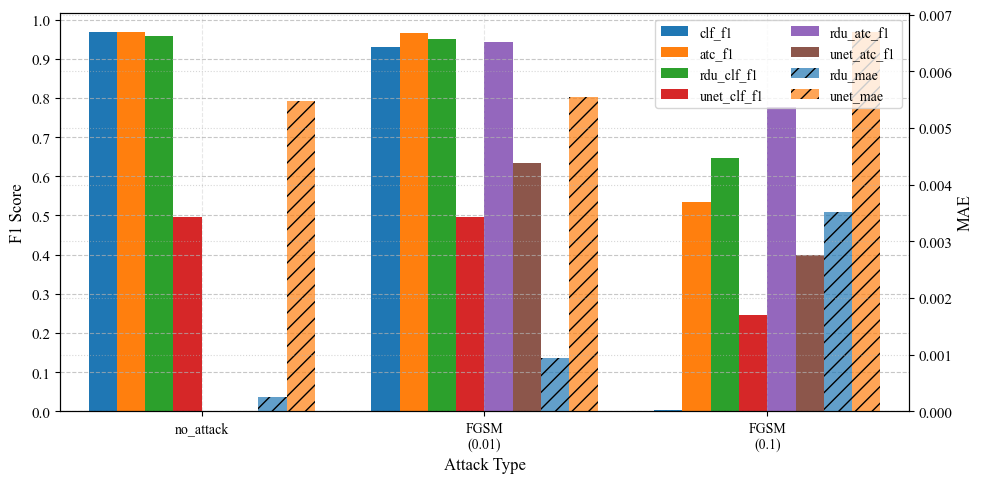

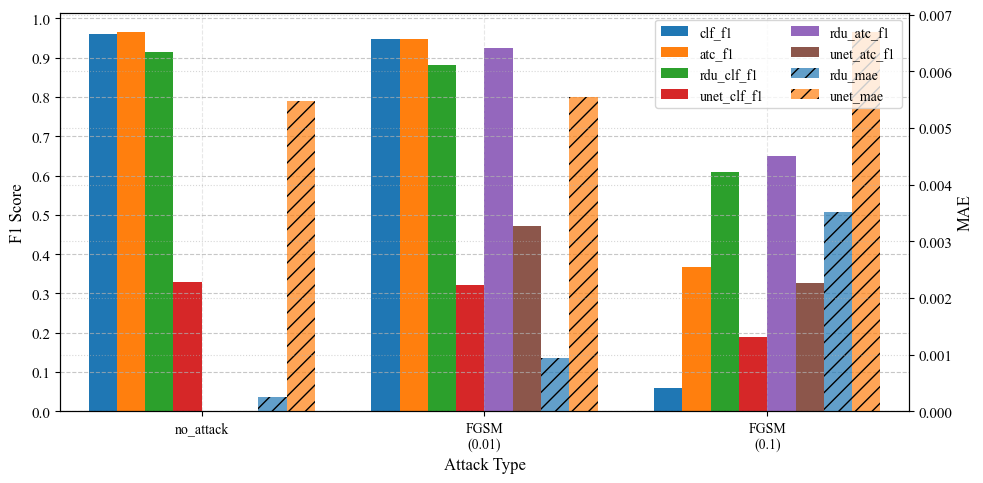

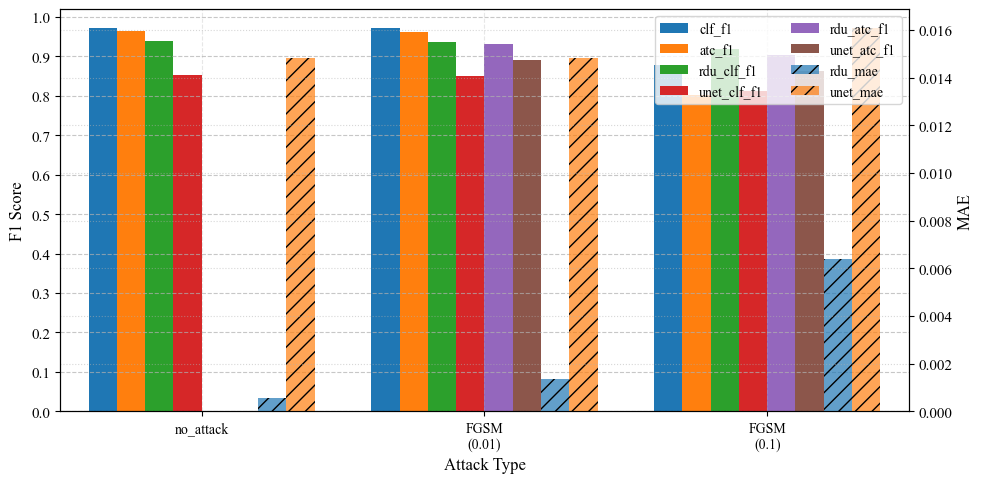

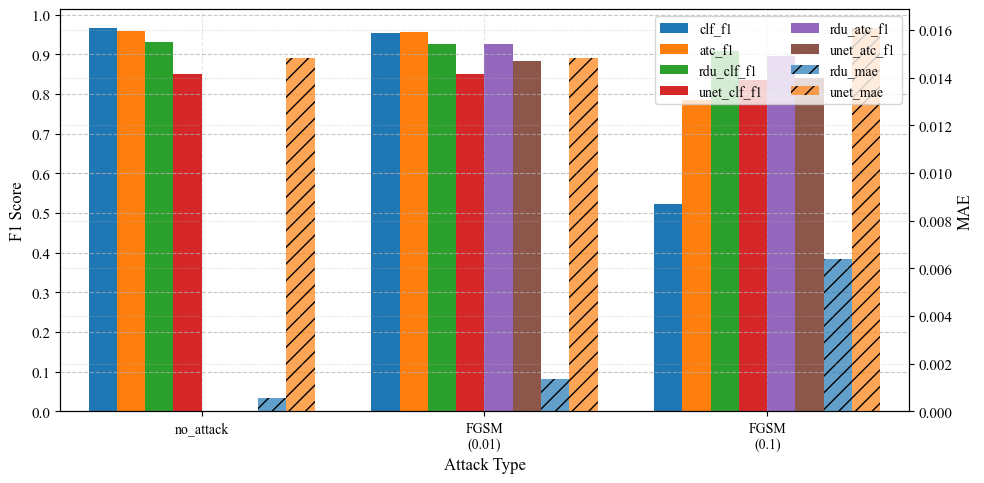

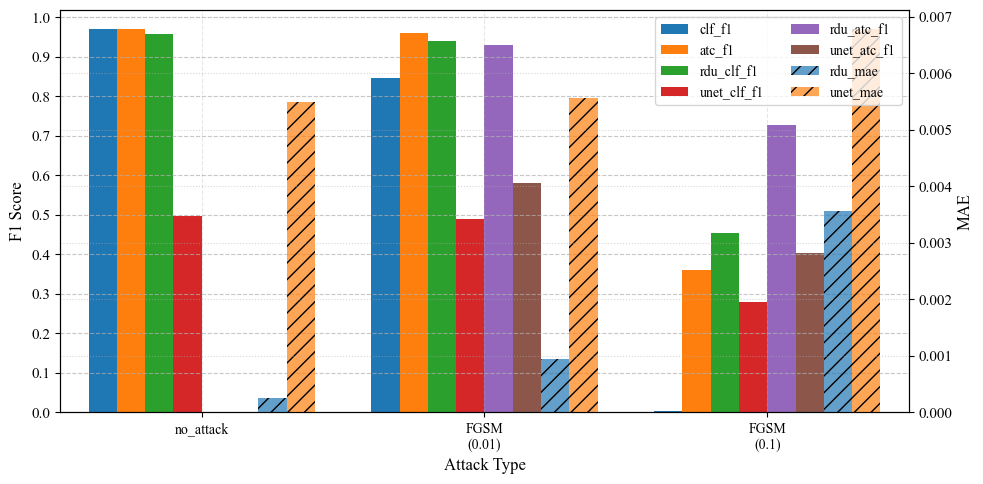

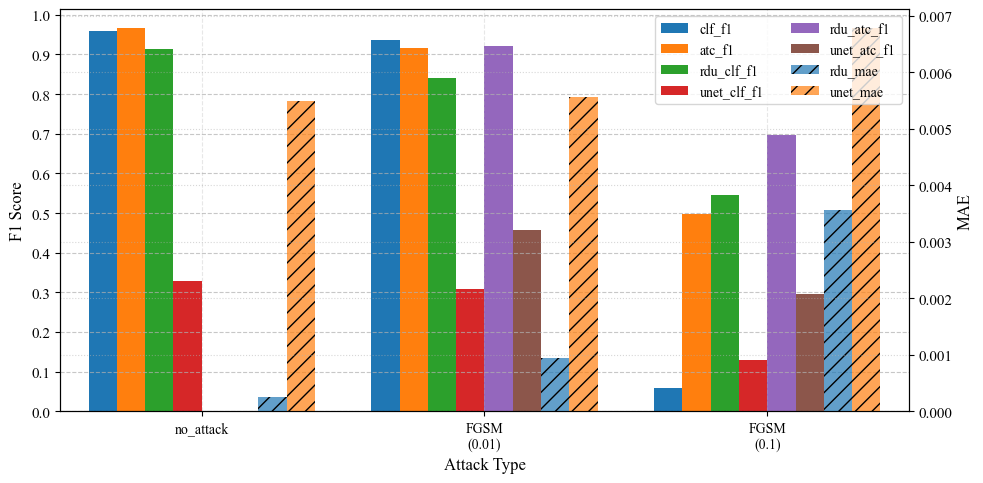

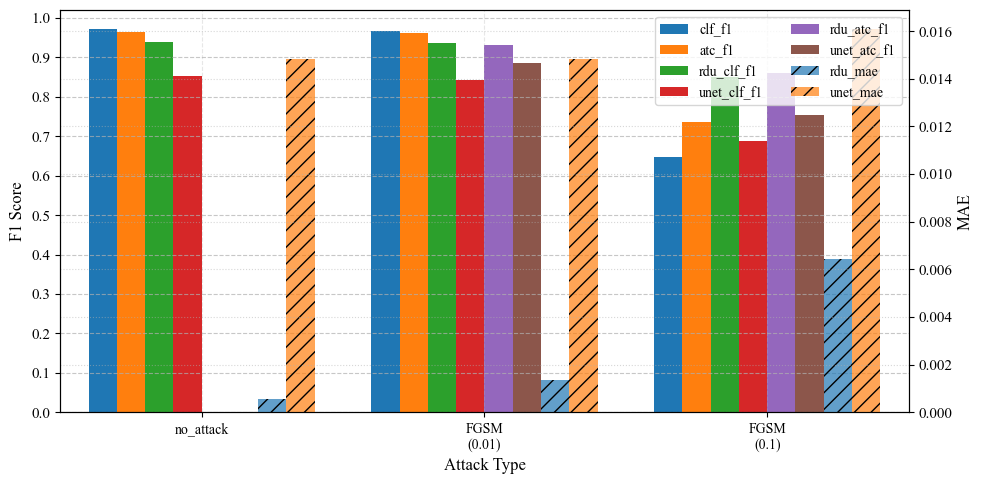

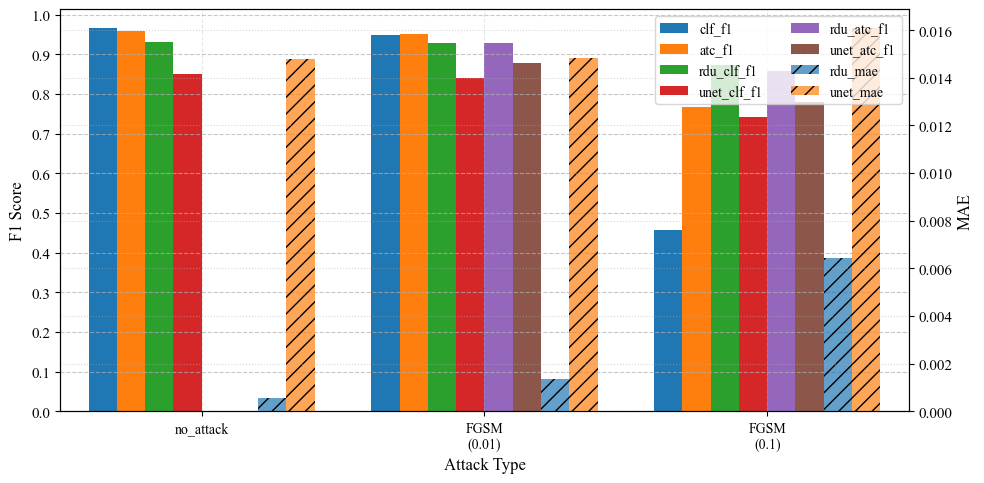

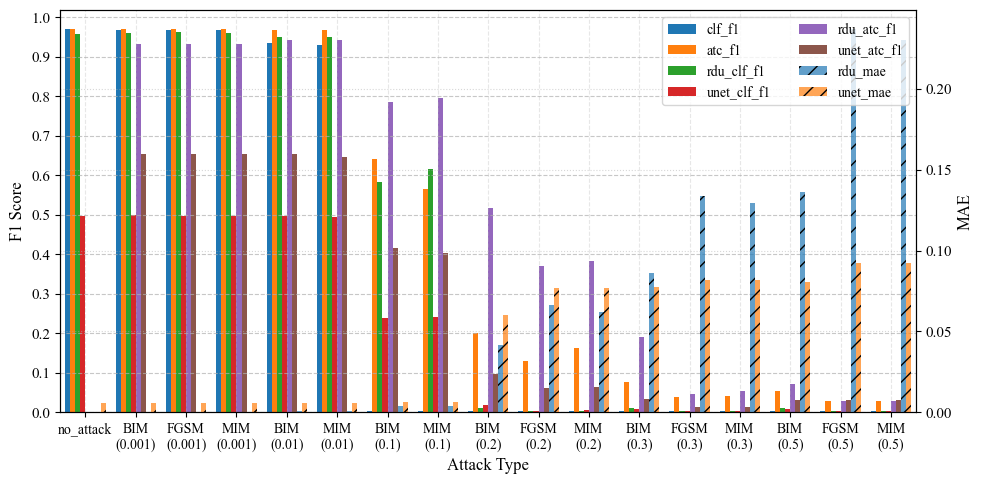

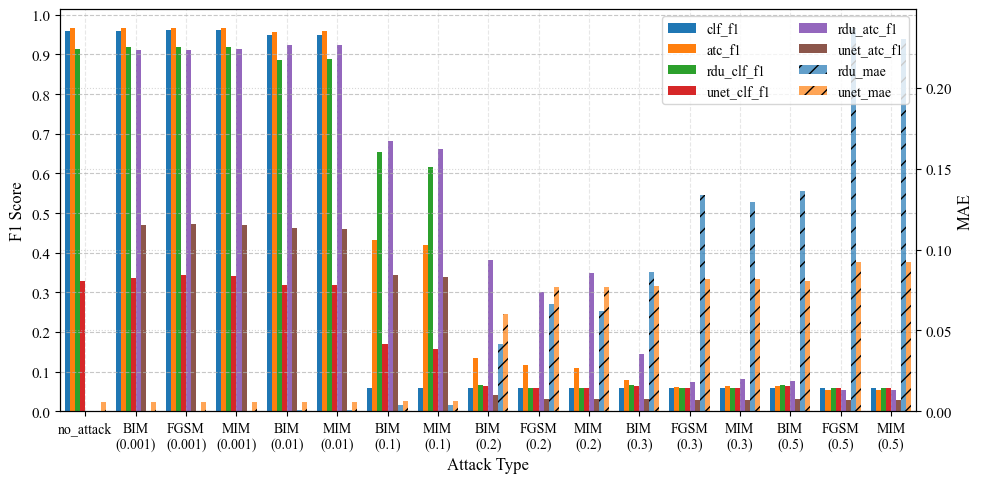

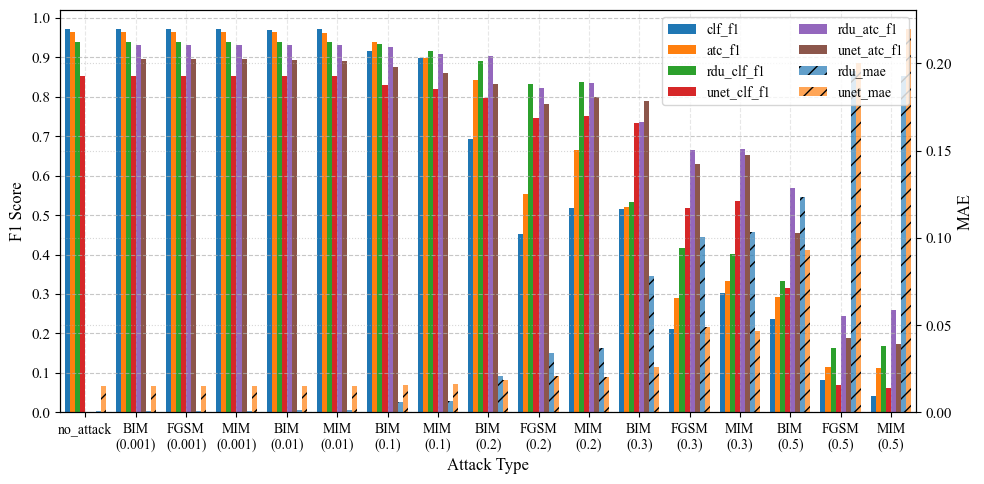

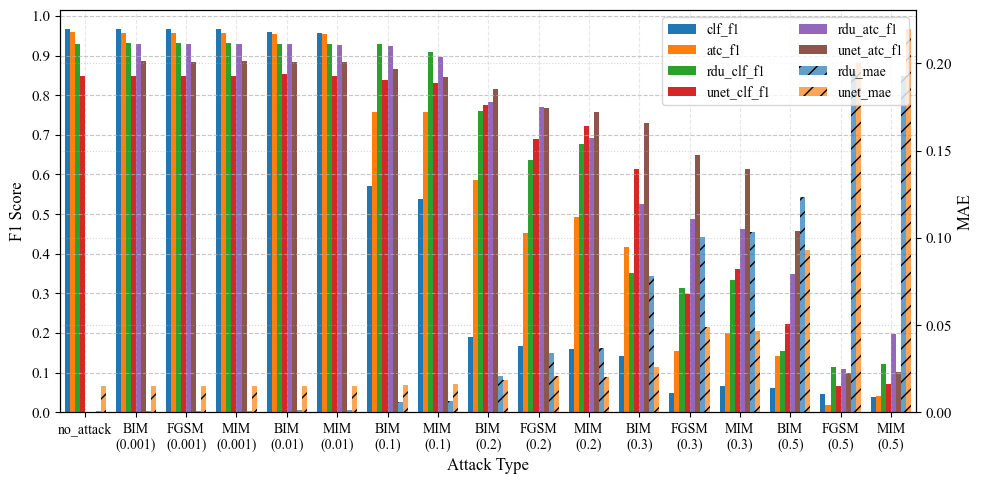

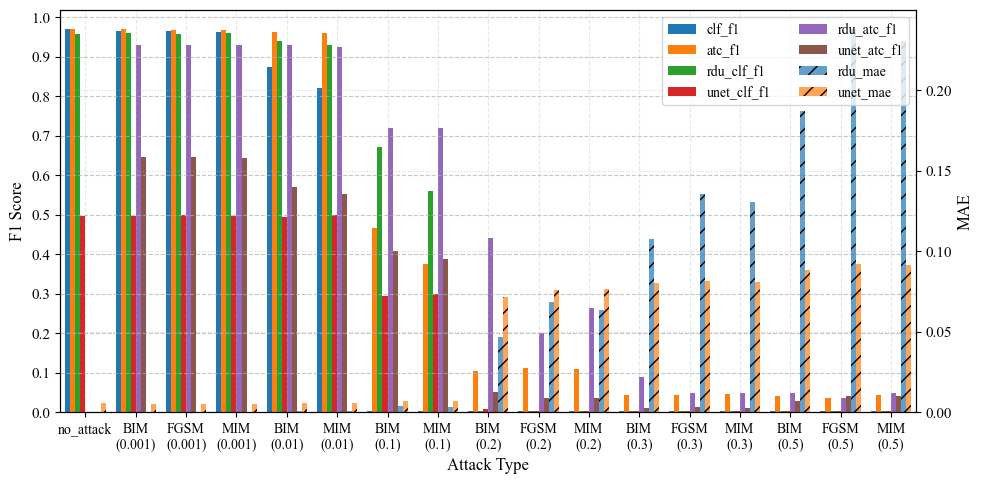

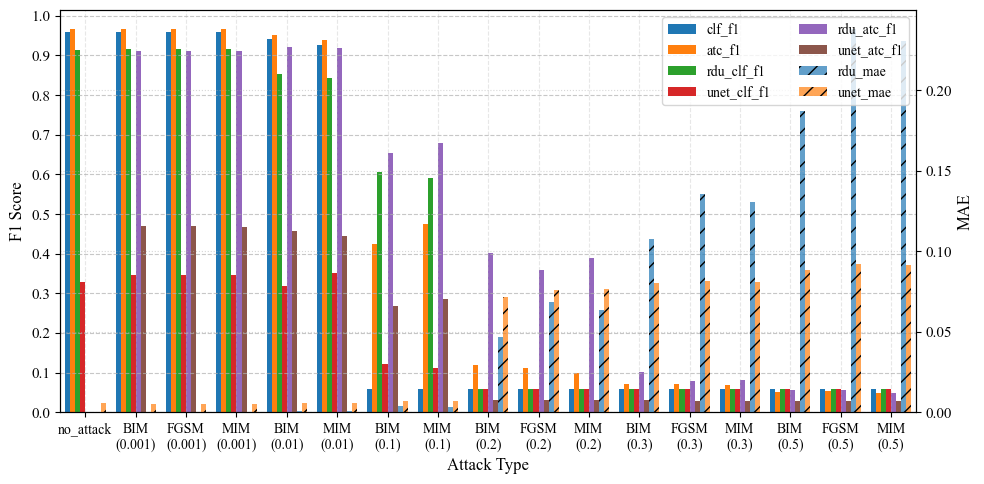

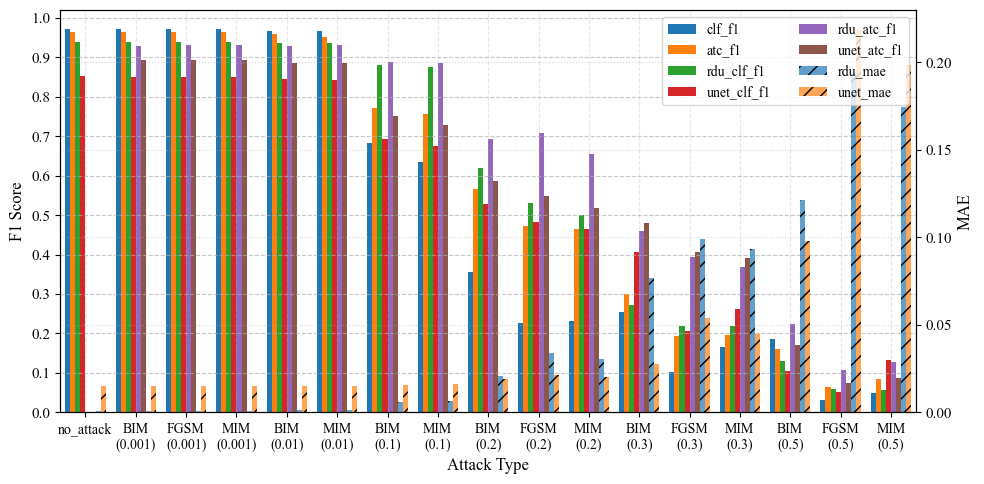

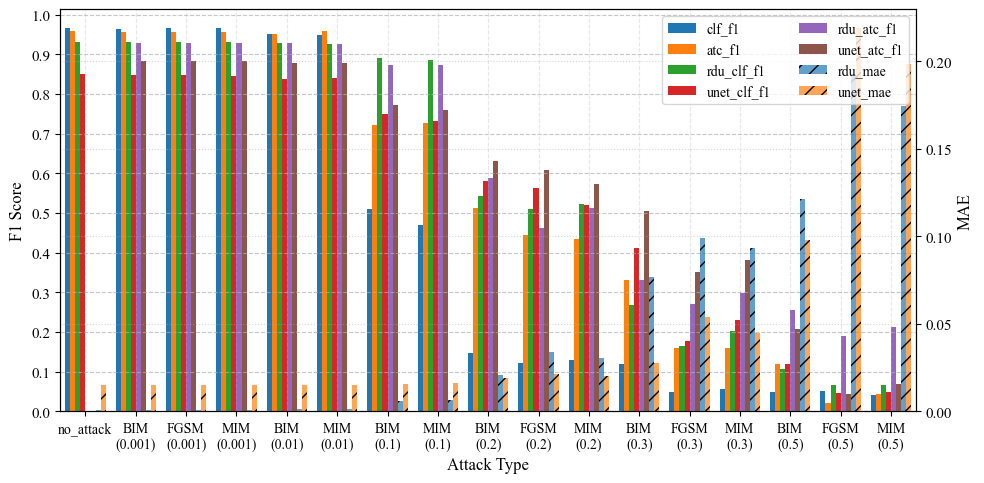

In [148]:
def generate_eval_plots(csv_files, curr_mode="train", show=True, ret_figs=True):
    fig_idx = 0
    bars_df = {}
    figs = {}
    suffix = f"{curr_mode}_"
    for csv_file in csv_files:
        adversarial_generator = csv_file.parent.name
        df = pd.read_csv(csv_file)
        print(adversarial_generator)

        model_types = ["resnet", "mobilenet"]
        ae_models = ["unet", "rdunet"]

        for model_type in model_types:
            bars = dict()
            result_file_name = f"{suffix}{adversarial_generator}_{model_type}.pdf"
            result_name = f"{adversarial_generator}_{model_type}"
            ndf = df[df.clf_model.apply(lambda x: model_type in x.lower())]

            # first get no atk results
            clf_f1 = ndf.clean_clf_f1.iloc[0]
            atc_f1 = ndf.clean_atc_f1.iloc[0]
            rdu_clf_f1 = ndf[
                ndf.ae_model.apply(lambda x: "rdunet" in x)
            ].recon_clean_clf_f1.iloc[0]
            unet_clf_f1 = ndf[
                ndf.ae_model.apply(lambda x: "rdunet" not in x)
            ].recon_clean_clf_f1.iloc[0]
            rdu_mae = ndf[ndf.ae_model.apply(lambda x: "rdunet" in x)].clean_mae.iloc[0]
            unet_mae = ndf[
                ndf.ae_model.apply(lambda x: "rdunet" not in x)
            ].clean_mae.iloc[0]

            bars["no_attack"] = dict(
                clf_f1=clf_f1,
                atc_f1=atc_f1,
                rdu_clf_f1=rdu_clf_f1,
                unet_clf_f1=unet_clf_f1,
                rdu_mae=rdu_mae,
                unet_mae=unet_mae,
            )

            for adversarial_name, nndf in ndf.groupby("adversarial_name"):
                eps = float(adversarial_name.split("eps_")[-1])
                adv_name = (
                    "BIM"
                    if "basic" in adversarial_name
                    else "FGSM" if "fast" in adversarial_name else "MIM"
                )
                adv_name = f"{adv_name}({eps})"
                data_split = "test"
                if adv_name in ["FGSM(0.1)", "FGSM(0.01)", "BIGM(0.1)", "BIGM(0.01)"]:

                    data_split = "train"

                if data_split != curr_mode:
                    continue

                # first read values from rdunet
                values = nndf[nndf.ae_model.apply(lambda x: "rdunet" in x)][
                    [
                        "adv_clf_f1",
                        "adv_atc_f1",
                        "recon_adv_clf_f1",
                        "recon_adv_atc_f1",
                        "adv_mae",
                    ]
                ].values[0]
                new_values = nndf[nndf.ae_model.apply(lambda x: "rdunet" not in x)][
                    ["recon_adv_clf_f1", "recon_adv_atc_f1", "adv_mae"]
                ].values[0]

                clf_f1 = values[0]
                atc_f1 = values[1]
                rdu_clf_f1 = values[2]
                rdu_atc_f1 = values[3]
                rdu_mae = values[4]
                unet_clf_f1 = new_values[0]
                unet_atc_f1 = new_values[1]
                unet_mae = new_values[2]

                bars[adv_name] = dict(
                    clf_f1=values[0],
                    atc_f1=values[1],
                    rdu_clf_f1=values[2],
                    rdu_atc_f1=values[3],
                    rdu_mae=values[4],
                    unet_clf_f1=new_values[0],
                    unet_atc_f1=new_values[1],
                    unet_mae=new_values[2],
                )

            print(fig_idx, result_file_name)

            bars_df[result_name], figs[result_name] = plot_bars(
                bars, "eval_" + result_file_name, show
            )

            fig_idx += 1
    if ret_figs:
        return bars_df, figs
    else:
        return bars_df, None


train_bars, train_figs = generate_eval_plots(csv_files, show=False, ret_figs=False)
test_bars, test_figs = generate_eval_plots(
    csv_files, curr_mode="test", show=False, ret_figs=False
)

In [145]:
columns = [
    "clf_f1",
    "atc_f1",
    "rdu_clf_f1",
    "unet_clf_f1",
    "rdu_atc_f1",
    "unet_atc_f1",
    "rdu_mae",
    "unet_mae",
]


for res_name, bar_df in train_bars.items():
    bar_df = bar_df[columns]
    bar_df.index = [x.replace("\n", "") for x in bar_df.index]
    train_bars[bar_df] = bar_df

TypeError: unhashable type: 'DataFrame'